# Análisis FBG: 4 + 4 Sensores - Fibra DW-3 Ormocer-T en el canal 2 y Poliamida POLY-1 en el canal 1 del interrogador (26/02/2026)

# Solo datos de picos y de espectros para caracterizar un espectro de fibra de poliamida

# para entender el interrogador y convert spectrum

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Archivo de datos para la fibra de poliamida POLY-1
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT para fibra POLY-1: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Verificar que el archivo existe
import os
if not os.path.exists(filepath):
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise FileNotFoundError(f"El archivo {filepath} no existe")

# Verificar tamaño del archivo
file_size = os.path.getsize(filepath)
print(f"📊 Tamaño del archivo: {file_size / (1024**2):.2f} MB")

if file_size < 1000:
    print(f"⚠️  ADVERTENCIA: El archivo parece muy pequeño ({file_size} bytes)")

# Cargar datos del archivo ROOT
try:
    print("\n🔄 Abriendo archivo ROOT...")
    file = uproot.open(filepath)
    print("✅ Archivo ROOT abierto correctamente")

    print("\n📋 Estructura del archivo ROOT:")
    print(f"   Keys disponibles: {file.keys()}")

    # ── Buscar el ciclo más reciente de 'peak' y 'spectrum' automáticamente ──
    # uproot devuelve "name;cycle" — tomamos el de mayor ciclo para cada TTree
    def latest_key(f, name):
        """Devuelve la key con el ciclo más alto para un TTree dado."""
        candidates = [k for k in f.keys() if k.split(";")[0] == name]
        if not candidates:
            return None
        return sorted(candidates, key=lambda k: int(k.split(";")[1]))[-1]

    print(f"\n🌳 Cargando TTrees individuales...")

    key_peak     = latest_key(file, "peak")
    key_spectrum = latest_key(file, "spectrum")

    if key_peak is None:
        raise KeyError("No se encontró ningún TTree llamado 'peak' en el archivo.")

    tree_peak = file[key_peak]
    print(f"   ✅ TTree '{key_peak}' cargado: {tree_peak.num_entries} entradas")
    print(f"   Branches: {tree_peak.keys()}")

    if key_spectrum is not None:
        tree_spectrum = file[key_spectrum]
        print(f"   ✅ TTree '{key_spectrum}' cargado: {tree_spectrum.num_entries} entradas")
        print(f"   Branches: {tree_spectrum.keys()}")
    else:
        tree_spectrum = None
        print(f"   ⚠️  No se encontró ningún TTree llamado 'spectrum'")

    # Extraer datos en arrays de NumPy
    print("\n📦 Extrayendo datos a arrays NumPy...")
    data_peak = tree_peak.arrays(library="np")

    if tree_spectrum is not None:
        data_spectrum = tree_spectrum.arrays(library="np")
        print(f"   ✅ Datos de espectros extraídos: {len(data_spectrum)} branches")
        print(f"   Keys espectros: {list(data_spectrum.keys())}")
    else:
        data_spectrum = None

    # Combinar en un solo diccionario para compatibilidad con el resto del código
    data = {}

    for key in data_peak.keys():
        data[key] = data_peak[key]

    if data_spectrum is not None:
        if 'wav' in data_spectrum and 't' in data_spectrum:
            data['spectrum_wav'] = data_spectrum['wav']
            data['spectrum_t']   = data_spectrum['t']
        for key in data_spectrum.keys():
            data[f"spectrum_{key}"] = data_spectrum[key]

    print(f"\n✅ Datos extraídos y combinados correctamente")
    print(f"   Total de branches: {len(data.keys())}")
    print(f"   Keys disponibles: {list(data.keys())}")

except FileNotFoundError:
    print(f"\n❌ ERROR CRÍTICO: No se puede acceder al archivo")
    print(f"   Ruta: {filepath}")
    print(f"   Verifica que:")
    print(f"   1. Estás ejecutando desde lxplus")
    print(f"   2. El archivo existe en /eos/")
    print(f"   3. Tienes permisos de lectura")
    raise
except Exception as e:
    print(f"\n❌ ERROR al cargar datos: {e}")
    print(f"   Tipo de error: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise

# Verificar que tenemos los datos esperados
print(f"\n🔍 Verificando datos cargados...")
print(f"   Keys totales: {len(data.keys())}")
print(f"   Keys disponibles: {list(data.keys())}")

📂 Cargando archivo ROOT para fibra POLY-1: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root
⏱️  TIME_SHIFT configurado: 2.0 horas
📊 Tamaño del archivo: 91.40 MB

🔄 Abriendo archivo ROOT...
✅ Archivo ROOT abierto correctamente

📋 Estructura del archivo ROOT:
   Keys disponibles: ['peak;3', 'spectrum;5']

🌳 Cargando TTrees individuales...
   ✅ TTree 'peak;3' cargado: 228750 entradas
   Branches: ['t', 'wav', 'sweep', 'ch', 'pos']
   ✅ TTree 'spectrum;5' cargado: 915 entradas
   Branches: ['t', 'wav']

📦 Extrayendo datos a arrays NumPy...
   ✅ Datos de espectros extraídos: 2 branches
   Keys espectros: ['t', 'wav']

✅ Datos extraídos y combinados correctamente
   Total de branches: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'spectrum_wav', 'spectrum_t']

🔍 Verificando datos cargados...
   Keys totales: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'spectrum_wav', 'spectrum_t']


## 3️⃣ Filtrar Rango Temporal

In [4]:
# 📊 Número de sensores FBG a analizar
num_sensores = 8  # Este experimento tiene 4 + 4 sensores FBG

# Extraer wavelengths y calcular media de polarizaciones
# Estructura de wav: (n_medidas, 2_polarizaciones, 5_sensores)
wav_raw = data_peak["wav"]

# wav_raw ya tiene forma (n_medidas, 2, num_sensores)
# Necesitamos reordenarlo a (n_medidas, num_sensores, 2) para media
wav_reshaped = np.transpose(wav_raw, (0, 2, 1))  # (n_medidas, num_sensores, 2_pol)

# Calcular media entre polarizaciones para cada sensor
wav_mean = np.mean(wav_reshaped, axis=2)  # (n_medidas, num_sensores)

# Extraer arrays de temperatura (8 RTDs)
#temp_raw = data_temp["temp"]

# Crear array de tiempos wavelength (ya con shift aplicado) para compatibilidad
# Buscar el branch correcto para los tiempos de wavelength
if 't' in data_peak:
    time_wavelength_shifted = data_peak['t']
elif 'timestamps' in data:
    time_wavelength_shifted = data['timestamps']
else:
    raise NameError("No se encontró el branch de tiempo para wavelength (ni 't' ni 'timestamps')")
times_all = time_wavelength_shifted

# Crear array de tiempos temperatura (sin shift)
#times_temp = time_temp

# Crear array de tiempos presión (sin shift)
#times_press = time_press

# Datos de presión
#press_raw = data_press["press"]

# press_raw tiene forma (n_medidas, 1) - extraer primera columna
#if len(press_raw.shape) > 1:
    #press_data_plot = press_raw[:, 0]
#else:
    #press_data_plot = press_raw
    
#print(f"✅ Datos de presión cargados: {len(press_data_plot):,} puntos")

print(f"\n📊 Resumen de datos cargados:")
print(f"   Wavelength (media pol): {wav_mean.shape} = {wav_mean.shape[0]:,} medidas × {num_sensores} sensores")
#print(f"   Temperatura: {temp_raw.shape} = {temp_raw.shape[0]:,} medidas × 8 RTDs")
#print(f"   Presión: {len(press_data_plot):,} medidas")
print(f"   Timestamps wavelength: {len(times_all):,}")
#print(f"   Timestamps temperatura: {len(times_temp):,}")
#print(f"   Timestamps presión: {len(times_press):,}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
use_full_range = True  # Cambiar a False para rango específico

if use_full_range:
    t_inicio = times_all[0]
    t_fin = times_all[-1]
else:
    fecha = datetime.date(2026, 3, 2)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(9, 50))
    t_fin = datetime.datetime.combine(fecha, datetime.time(11, 5))

# Filtrar wavelength (tiene TIME_SHIFT aplicado)
mask_time = (times_all >= t_inicio) & (times_all <= t_fin)
times_filtered = times_all[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar presión
#mask_time_press = (times_press >= t_inicio) & (times_press <= t_fin)
#press_filtered = press_data_plot[mask_time_press]
#times_press_filtered = times_press[mask_time_press]

# Imprimir rango seleccionado con conversión segura a string
def safe_strftime(dt, fmt):
    import datetime
    if isinstance(dt, datetime.datetime):
        return dt.strftime(fmt)
    elif hasattr(dt, 'astype'):
        try:
            dt_obj = dt.astype('datetime64[s]').astype(datetime.datetime)
            return dt_obj.strftime(fmt)
        except Exception:
            return str(dt)
    else:
        return str(dt)

print(f"\n✅ Rango seleccionado: {safe_strftime(t_inicio, '%Y-%m-%d %H:%M')} - {safe_strftime(t_fin, '%H:%M')}")
print(f"   Puntos wavelength: {len(times_filtered):,}")
#print(f"   Puntos temperatura: {len(times_temp_filtered):,}")
#print(f"   Puntos presión: {len(times_press_filtered):,}")
if len(times_filtered) == 0:
    print(f"\n⚠️  Sin datos en el rango. Activa 'use_full_range = True' o ajusta t_inicio/t_fin.")


📊 Resumen de datos cargados:
   Wavelength (media pol): (228750, 8) = 228,750 medidas × 8 sensores
   Timestamps wavelength: 228,750

✅ Rango seleccionado: [1.77243787e+09 1.77243787e+09] - [1.77246133e+09 1.77246133e+09]
   Puntos wavelength: 457,500


## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [5]:
# ✅ CONFIGURACIÓN: 8 sensores FBG completos (4 + 4)
# 8 sensores × 2 polarizaciones = 16 canales
# Índices 0-based: sensor 0, 1, 2, 3, 4, 5, 6, 7 (Python indexing)
fbg_config = []
for sensor in range(8):
    fbg_config.append({"pol": 0, "sensor": sensor, "label": f"FBG-{sensor+1}-P"})
    fbg_config.append({"pol": 1, "sensor": sensor, "label": f"FBG-{sensor+1}-S"})
print(f"✅ Configurados {len(fbg_config)} canales FBG (8 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si hay datos válidos para todos los sensores en este dataset")

✅ Configurados 16 canales FBG (8 sensores × 2 polarizaciones)
💡 Se verificará si hay datos válidos para todos los sensores en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [6]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0, use_robust=True):
    """
    Filtra wavelength usando método μ±3σ o método robusto basado en mediana (MAD)
    
    Parameters:
    -----------
    wav_data : array
        Datos de wavelength a filtrar
    timestamps : array
        Timestamps correspondientes
    sigma_threshold : float
        Número de sigmas (o MADs) para el threshold
    use_robust : bool
        Si True, usa MAD (Median Absolute Deviation) en lugar de std
    """
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    if use_robust:
        # Método robusto: usa MEDIANA y MAD (más resistente a outliers)
        median_wav = np.median(wav_positive)
        mad = np.median(np.abs(wav_positive - median_wav))
        # Convertir MAD a escala comparable con std (factor 1.4826)
        sigma_equiv = 1.4826 * mad
        
        threshold_min = median_wav - sigma_threshold * sigma_equiv
        threshold_max = median_wav + sigma_threshold * sigma_equiv
        
        # Filtrar usando los thresholds robustos
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
        
        # Calcular estadísticas finales sobre datos filtrados
        wav_filtered = wav_data[mask_filtered]
        mean_wav = np.mean(wav_filtered)
        std_wav = np.std(wav_filtered)
    else:
        # Método clásico: μ±3σ
        mean_wav = np.mean(wav_positive)
        std_wav = np.std(wav_positive)
        threshold_min = mean_wav - sigma_threshold * std_wav
        threshold_max = mean_wav + sigma_threshold * std_wav
        
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }
    
    # DIAGNÓSTICO: Verificar forma y valores de los sensores
    print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
    print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")
    print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1 a FBG-8):")
    for sensor_idx in range(8):
        for pol_idx in range(2):
            pol_name = "P" if pol_idx == 0 else "S"
            sensor_data = wav_filtered[:, pol_idx, sensor_idx]
            n_positive = np.sum(sensor_data > 0)
            if n_positive > 0:
                min_val = np.min(sensor_data[sensor_data > 0])
                max_val = np.max(sensor_data)
                mean_val = np.mean(sensor_data[sensor_data > 0])
            else:
                min_val = max_val = mean_val = 0
            print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2e}, {max_val:.2e}] nm, μ={mean_val:.2e} nm")

### 5.3 Calcular Media de Polarizaciones

In [7]:
# Filtrar datos wavelength para cada sensor y polarización (8 sensores × 2 pol)
# Diagnóstico de shapes y tipos
print(f"wav_raw shape: {wav_raw.shape}")
print(f"times_all shape: {times_all.shape}")
print(f"times_all[0]: {times_all[0]}")

# Usar solo la primera columna de times_all para el tiempo de wavelength (P)
times_wav = times_all[:, 0]  # shape (153125,)
print(f"times_wav shape: {times_wav.shape}, dtype: {times_wav.dtype}, first: {times_wav[0]}")

# Definir t_inicio y t_fin como escalares para la columna usada
t_inicio = times_all[0, 0]
t_fin = times_all[-1, 0]
print(f"t_inicio: {t_inicio}, t_fin: {t_fin}, type: {type(t_inicio)}")

# Si times_wav es float (timestamp), no convertir
times_wav_dt = times_wav

# Crear máscara temporal
mask_time = (times_wav_dt >= t_inicio) & (times_wav_dt <= t_fin)
print(f"mask_time shape: {mask_time.shape}, sum: {np.sum(mask_time)}")

fbg_filtered_data = {}
for config in fbg_config:
    pol = config['pol']
    sensor = config['sensor']
    label = config['label']
    wav_sensor_pol = wav_raw[:, pol, sensor][mask_time]
    timestamps_sensor = times_wav_dt[mask_time]
    filtered = filter_wavelength_data(wav_sensor_pol, timestamps_sensor, sigma_threshold=3.0, use_robust=True)
    fbg_filtered_data[label] = filtered
print(f"✅ Datos filtrados para {len(fbg_filtered_data)} canales (8 sensores × 2 pol)")

wav_raw shape: (228750, 2, 8)
times_all shape: (228750, 2)
times_all[0]: [1.77243787e+09 1.77243787e+09]
times_wav shape: (228750,), dtype: float64, first: 1772437866.701463
t_inicio: 1772437866.701463, t_fin: 1772461331.489861, type: <class 'numpy.float64'>
mask_time shape: (228750,), sum: 228750
✅ Datos filtrados para 16 canales (8 sensores × 2 pol)


In [8]:
# Calcular media P+S para cada sensor (8 sensores: 1 a 8)
fbg_mean_data = {}

for sensor_num in range(1, 9):  # Sensores 1 a 8
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    # Interpolar S a tiempos de P (usar directamente los float timestamps)
    times_p_sec = np.array(times_p)
    times_s_sec = np.array(times_s)
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6e} {data['std']:<15.6e} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1.545073e-06    2.510868e-12    142750
FBG-2-Mean      1.550922e-06    4.819419e-13    142750
FBG-3-Mean      1.556464e-06    1.313085e-11    142750
FBG-4-Mean      1.560772e-06    2.385462e-12    133048
FBG-5-Mean      1.545045e-06    1.214569e-12    142750
FBG-6-Mean      1.550765e-06    3.638103e-13    142750
FBG-7-Mean      1.556542e-06    3.262838e-13    142750
FBG-8-Mean      1.562361e-06    2.820250e-13    142711


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

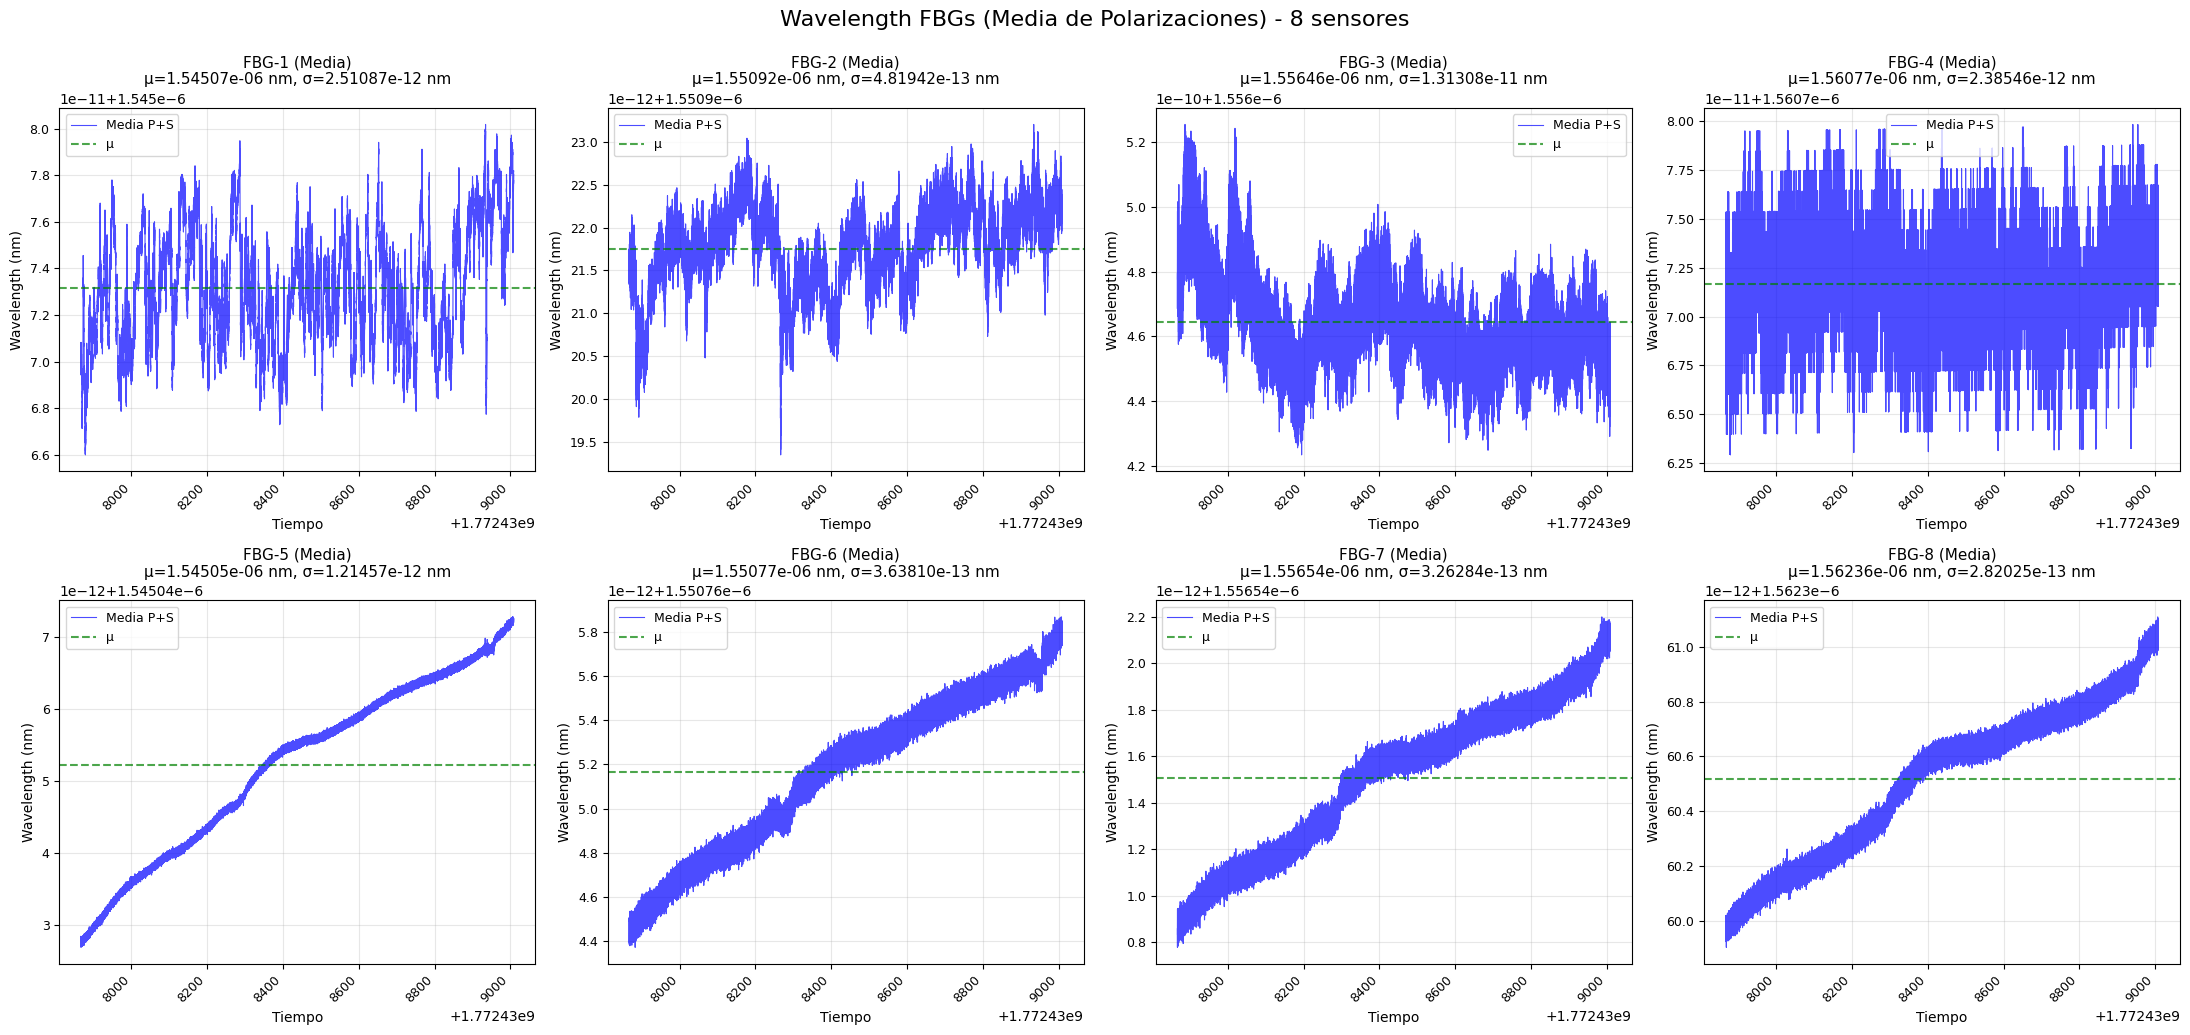

💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales


In [9]:
# Visualizar Wavelengths (Media de Polarizaciones) para 8 sensores
n_sensors = len(fbg_mean_data)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    # Añadir líneas verticales de plateaus (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            axes[idx].axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.2, alpha=0.5)
            axes[idx].axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.5e} nm, σ={data['std']:.5e} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores', fontsize=16, y=1.03)
plt.show()

if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales")

spectrum_wav shape: (915, 2, 2, 39200)


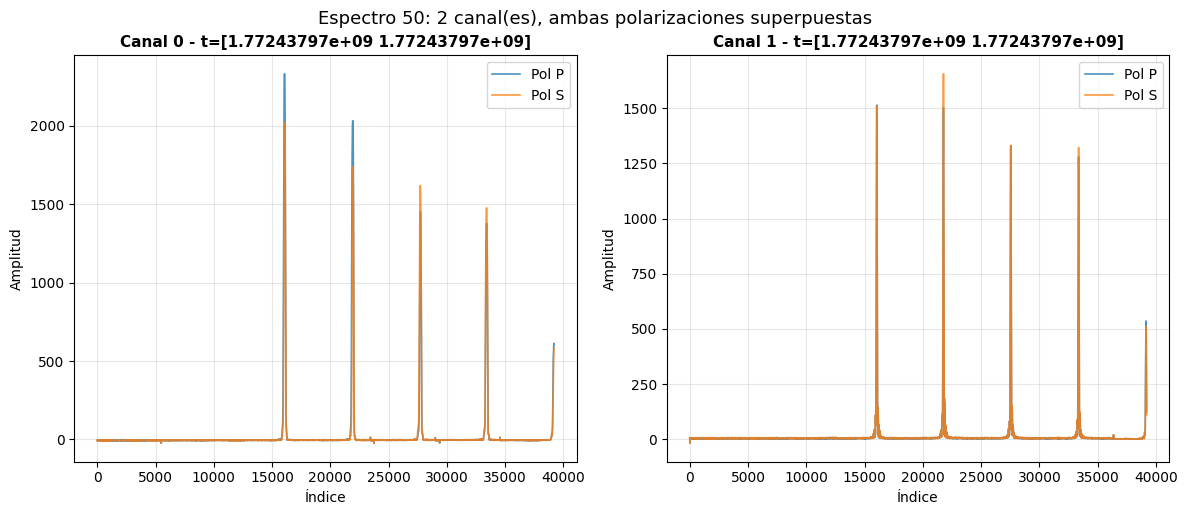

✅ Mostrando 2 canal(es) disponible(s) de 2 total(es)


In [10]:
# Plotear espectro completo para canales 0, 1 y 2, ambas polarizaciones superpuestas
# Reutiliza spectrum_wav y data_spectrum ya cargados en la celda anterior
import matplotlib.pyplot as plt

# Usar spectrum_wav del data_spectrum ya cargado (evita reabrir el fichero)
spectrum_wav = data_spectrum['wav']  # shape: (n_espectros, n_pol, n_chan, n_puntos)
spectrum_t   = data_spectrum['t']    # shape: (n_espectros,)
shape = spectrum_wav.shape
print(f"spectrum_wav shape: {shape}")

if len(shape) == 4:
    n_espectros, n_pol, n_chan, n_puntos = shape
    idx_espectro = 50
    
    # Solo mostrar los canales que existen
    canales_a_mostrar = list(range(min(n_chan, 3)))  # Máximo 3 canales
    pol_labels = ['Pol P', 'Pol S']
    
    # Ajustar número de subplots según canales disponibles
    n_plots = len(canales_a_mostrar)
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    
    # Si solo hay un canal, axes no será un array
    if n_plots == 1:
        axes = [axes]
    
    for i, idx_chan in enumerate(canales_a_mostrar):
        ax = axes[i]
        for idx_pol in range(n_pol):
            wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
            ax.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
        t = spectrum_t[idx_espectro]
        ax.set_title(f'Canal {idx_chan} - t={t}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Índice', fontsize=10)
        ax.set_ylabel('Amplitud', fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.suptitle(f'Espectro {idx_espectro}: {n_plots} canal(es), ambas polarizaciones superpuestas', 
                 fontsize=13, y=1.02)
    plt.show()
    print(f"✅ Mostrando {n_plots} canal(es) disponible(s) de {n_chan} total(es)")
else:
    print("Estructura inesperada en spectrum_wav. Esperado 4D (espectro, pol, canal, puntos).")

📊 Generando plots individuales para 2 canal(es) disponible(s)
   Shape: (915, 2, 2, 39200) → 915 espectros, 2 pols, 2 canales, 39200 puntos


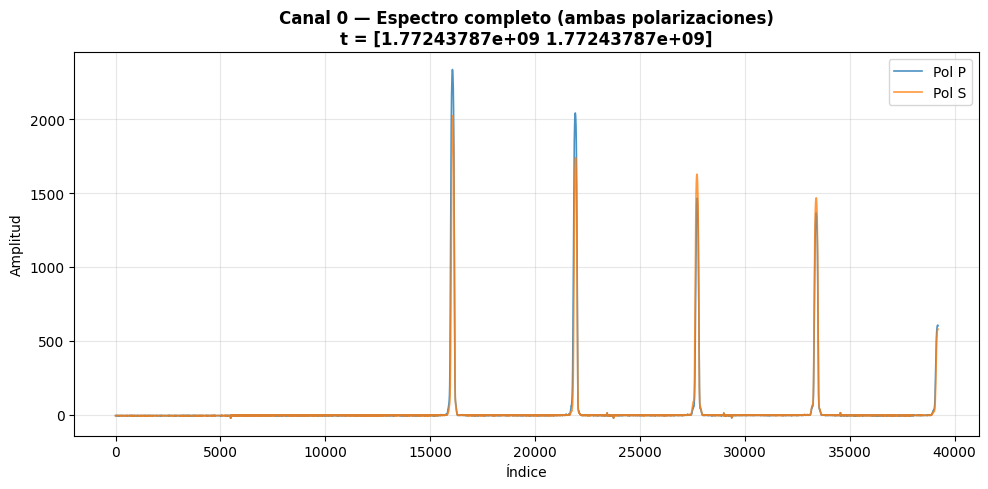

✅ Canal 0 plotado (espectro 0, t=[1.77243787e+09 1.77243787e+09])


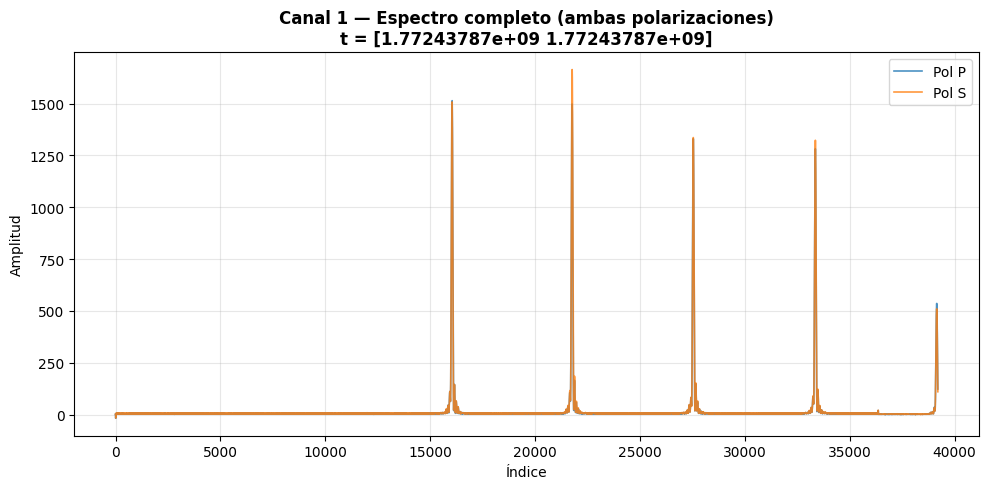

✅ Canal 1 plotado (espectro 0, t=[1.77243787e+09 1.77243787e+09])


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Espectros individuales por canal (solo canales disponibles)
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

spectrum_wav = data_spectrum['wav']
spectrum_t = data_spectrum['t']

shape = spectrum_wav.shape
n_espectros, n_pol, n_chan, n_puntos = shape
idx_espectro = 0  # Primer espectro

pol_labels = ['Pol P', 'Pol S']

print(f"📊 Generando plots individuales para {n_chan} canal(es) disponible(s)")
print(f"   Shape: {shape} → {n_espectros} espectros, {n_pol} pols, {n_chan} canales, {n_puntos} puntos")
print("="*80)

# Plotear cada canal disponible
for idx_chan in range(n_chan):
    plt.figure(figsize=(10, 5))
    
    for idx_pol in range(n_pol):
        wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
        plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
    
    t = spectrum_t[idx_espectro]
    plt.title(f'Canal {idx_chan} — Espectro completo (ambas polarizaciones)\nt = {t}', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Índice', fontsize=10)
    plt.ylabel('Amplitud', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Canal {idx_chan} plotado (espectro {idx_espectro}, t={t})")

print("="*80)

📊 Canales disponibles: 2
   Configuración: {0: 'POLY-1', 1: 'DW-3'}
POLY-1 Pol P: peak idx=16066, FWHM=177.67 pts
POLY-1 Pol S: peak idx=16078, FWHM=153.45 pts
DW-3 Pol P: peak idx=16044, FWHM=76.80 pts
DW-3 Pol S: peak idx=16042, FWHM=76.77 pts


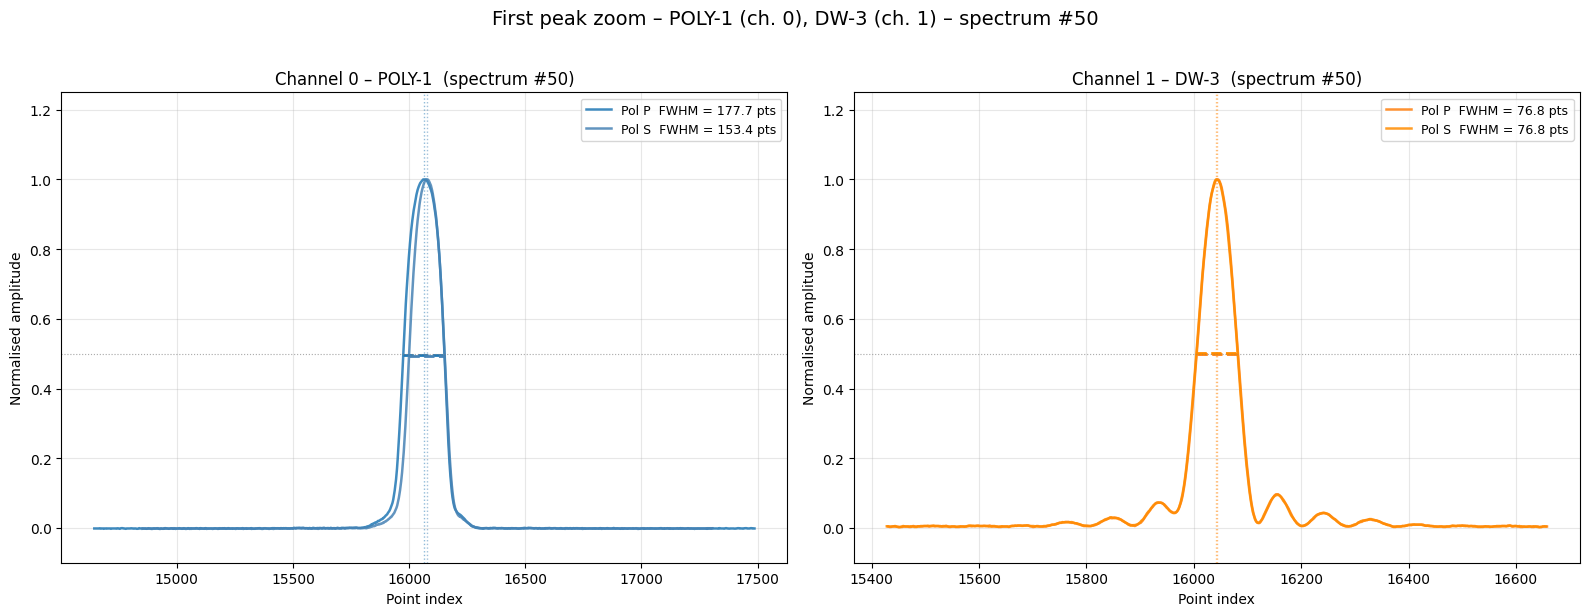

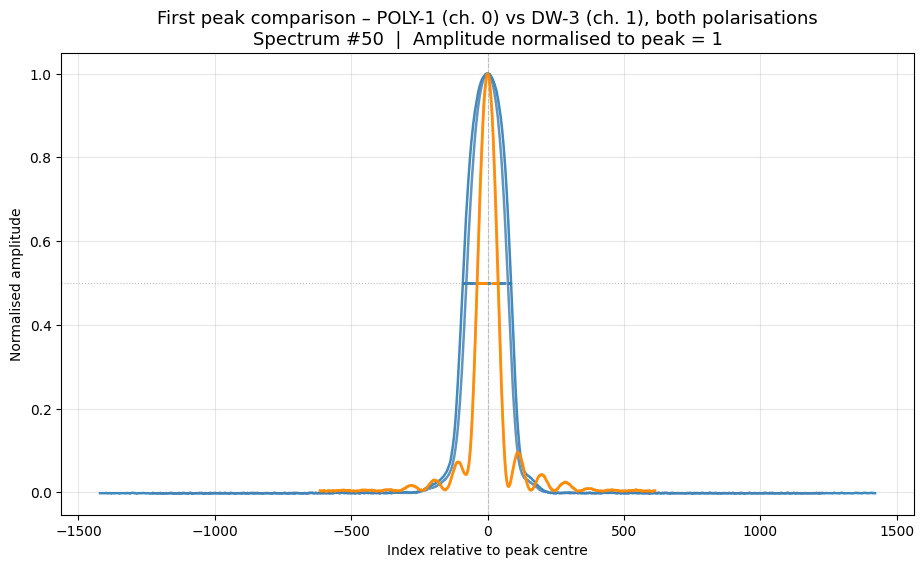

In [12]:
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt
import numpy as np

# ──────────────────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────────────────
idx_espectro = 50          # Spectrum index to analyse

# Detectar canales disponibles automáticamente
n_chan_available = spectrum_wav.shape[2]
channel_names_full = {0: 'POLY-1', 1: 'DW-3', 2: 'Canal-2'}
channel_info = {i: channel_names_full.get(i, f'Canal-{i}') 
                for i in range(n_chan_available)}

pol_labels   = ['Pol P', 'Pol S']
colors_chan  = {0: ['tab:blue',   'steelblue'],
                1: ['tab:orange', 'darkorange'],
                2: ['tab:green',  'darkgreen']}

print(f"📊 Canales disponibles: {n_chan_available}")
print(f"   Configuración: {channel_info}")
print("="*80)

# ──────────────────────────────────────────────────────────
# Helper: find first *real* peak above noise floor + FWHM
# Uses height > 5 % of max to skip noise bumps at array edges
# ──────────────────────────────────────────────────────────
def get_first_peak(signal, min_prominence_factor=0.10, min_distance=10, min_height_factor=0.05):
    """Return (peak_idx, fwhm, width_height, left_ip, right_ip) for the first real peak."""
    sig_max    = np.max(signal)
    height     = sig_max * min_height_factor
    prominence = sig_max * min_prominence_factor
    peaks, _   = find_peaks(signal, prominence=prominence, distance=min_distance, height=height)
    if len(peaks) == 0:
        return None
    first = peaks[0]
    widths, w_heights, left_ips, right_ips = peak_widths(signal, [first], rel_height=0.5)
    return first, widths[0], w_heights[0], left_ips[0], right_ips[0]

# ──────────────────────────────────────────────────────────
# PLOT 1: zoomed first peak per channel (normalised, separate subplots)
# ──────────────────────────────────────────────────────────
n_subplots = len(channel_info)
fig, axes = plt.subplots(1, n_subplots, figsize=(8*n_subplots, 6))

# Si solo hay un canal, axes no es un array
if n_subplots == 1:
    axes = [axes]

for ax, (idx_chan, fiber_name) in zip(axes, channel_info.items()):
    for idx_pol in range(spectrum_wav.shape[1]):
        signal = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
        x      = np.arange(len(signal))
        result = get_first_peak(signal)

        if result is None:
            ax.plot(x, signal / np.max(signal), alpha=0.6,
                    label=f'{pol_labels[idx_pol]} (no peak found)')
            print(f"{fiber_name} {pol_labels[idx_pol]}: no peak found")
            continue

        peak_idx, fwhm, w_height, left_ip, right_ip = result
        zoom = max(int(fwhm * 8), 40)
        x0, x1    = max(0, peak_idx - zoom), min(len(signal), peak_idx + zoom + 1)
        x_zoom    = x[x0:x1]
        peak_val  = signal[peak_idx]
        y_norm    = signal[x0:x1] / peak_val          # normalise to peak = 1
        w_h_norm  = w_height / peak_val

        # Obtener color (con fallback si el canal no está definido)
        color = colors_chan.get(idx_chan, ['tab:gray', 'darkgray'])[idx_pol]
        ax.plot(x_zoom, y_norm, color=color, linewidth=1.8, alpha=0.85,
                label=f'{pol_labels[idx_pol]}  FWHM = {fwhm:.1f} pts')
        ax.hlines(w_h_norm, left_ip, right_ip, color=color, linestyle='--', linewidth=2)
        ax.axvline(peak_idx, color=color, linestyle=':', linewidth=1, alpha=0.5)
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.4)

        print(f"{fiber_name} {pol_labels[idx_pol]}: peak idx={peak_idx}, FWHM={fwhm:.2f} pts")

    ax.set_title(f'Channel {idx_chan} – {fiber_name}  (spectrum #{idx_espectro})', fontsize=12)
    ax.set_xlabel('Point index')
    ax.set_ylabel('Normalised amplitude')
    ax.set_ylim(-0.1, 1.25)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Título dinámico según canales disponibles
canal_names = ', '.join([f'{name} (ch. {i})' for i, name in channel_info.items()])
plt.suptitle(f'First peak zoom – {canal_names} – spectrum #{idx_espectro}',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────
# PLOT 2: first peaks superposed (centred on peak, normalised)
# ──────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 6))
ax2.axvline(0,   color='gray', linestyle='--', linewidth=0.8, alpha=0.4, label='Peak centre')
ax2.axhline(0.5, color='gray', linestyle=':',  linewidth=0.8, alpha=0.5, label='FWHM level (0.5)')

for idx_chan, fiber_name in channel_info.items():
    for idx_pol in range(spectrum_wav.shape[1]):
        signal = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
        result = get_first_peak(signal)
        if result is None:
            continue
        peak_idx, fwhm, w_height, left_ip, right_ip = result
        zoom = max(int(fwhm * 8), 40)
        x0, x1   = max(0, peak_idx - zoom), min(len(signal), peak_idx + zoom + 1)
        x_rel    = np.arange(x0 - peak_idx, x1 - peak_idx)   # centred at 0
        y_norm   = signal[x0:x1] / signal[peak_idx]            # normalise to peak = 1
        
        # Obtener color (con fallback si el canal no está definido)
        color = colors_chan.get(idx_chan, ['tab:gray', 'darkgray'])[idx_pol]
        label = f'{fiber_name} {pol_labels[idx_pol]}  FWHM={fwhm:.1f} pts'
        ax2.plot(x_rel, y_norm, color=color, linewidth=1.8, alpha=0.85, label=label)
        ax2.hlines(0.5, left_ip - peak_idx, right_ip - peak_idx,
                   color=color, linestyle='--', linewidth=2)

ax2.set_xlabel('Index relative to peak centre')
ax2.set_ylabel('Normalised amplitude')
# Título dinámico para PLOT 2
canal_comparison = ' vs '.join([f'{name} (ch. {i})' for i, name in channel_info.items()])
ax2.set_title(f'First peak comparison – {canal_comparison}, both polarisations\n'
              f'Spectrum #{idx_espectro}  |  Amplitude normalised to peak = 1', fontsize=13)
ax2.grid(True, alpha=0.3)
plt.show()

plt.show()


---

# 🔬 DW-3 Fiber Quality Analysis

Complete quality control analysis for **DW-3** fiber on channel 1:
- 4 FBG sensors detection
- QC-1: Sensor spacing uniformity
- QC-2: FWHM < 100 pm
- QC-3: SLSR > 20 dB (Side-Lobe Suppression Ratio)
- QC-4: Spectral Asymmetry Ratio (SAR) 1–3%
- QC-5: Design wavelength deviation < 50 pm
- FBG length estimation from FWHM
- Mirror symmetry visualization

✅ Using spectrum index : 50  (same as above)
   Channel              : 1  (DW-3)
   λ-axis               : 1529.0–1568.2 nm  (39200 pts, Δλ = 1.000 pm/pt)
   Analysing            : 5 sensors (FBG-1 to FBG-5, all gratings)

🔍 DW-3 peaks detected (ch 1, spectrum #50):
   Pol P: ['1545.0444 nm', '1550.7646 nm', '1556.5417 nm', '1562.3589 nm', '1568.1460 nm']
   Pol S: ['1545.0424 nm', '1550.7686 nm', '1556.5427 nm', '1562.3609 nm', '1568.1460 nm']

══════════════════════════════════════════════════════════════════════
  DW-3  —  Peak Wavelengths   (ch 1, spectrum #50)
══════════════════════════════════════════════════════════════════════
  Sensor           λ_P (nm)       λ_S (nm)     λ_mean (nm)
  ----------------------------------------------------------
  FBG-1          1545.04441     1545.04241      1545.04341
  FBG-2          1550.76456     1550.76856      1550.76656
  FBG-3          1556.54170     1556.54270      1556.54220
  FBG-4          1562.35885     1562.36085      1562.35985
 

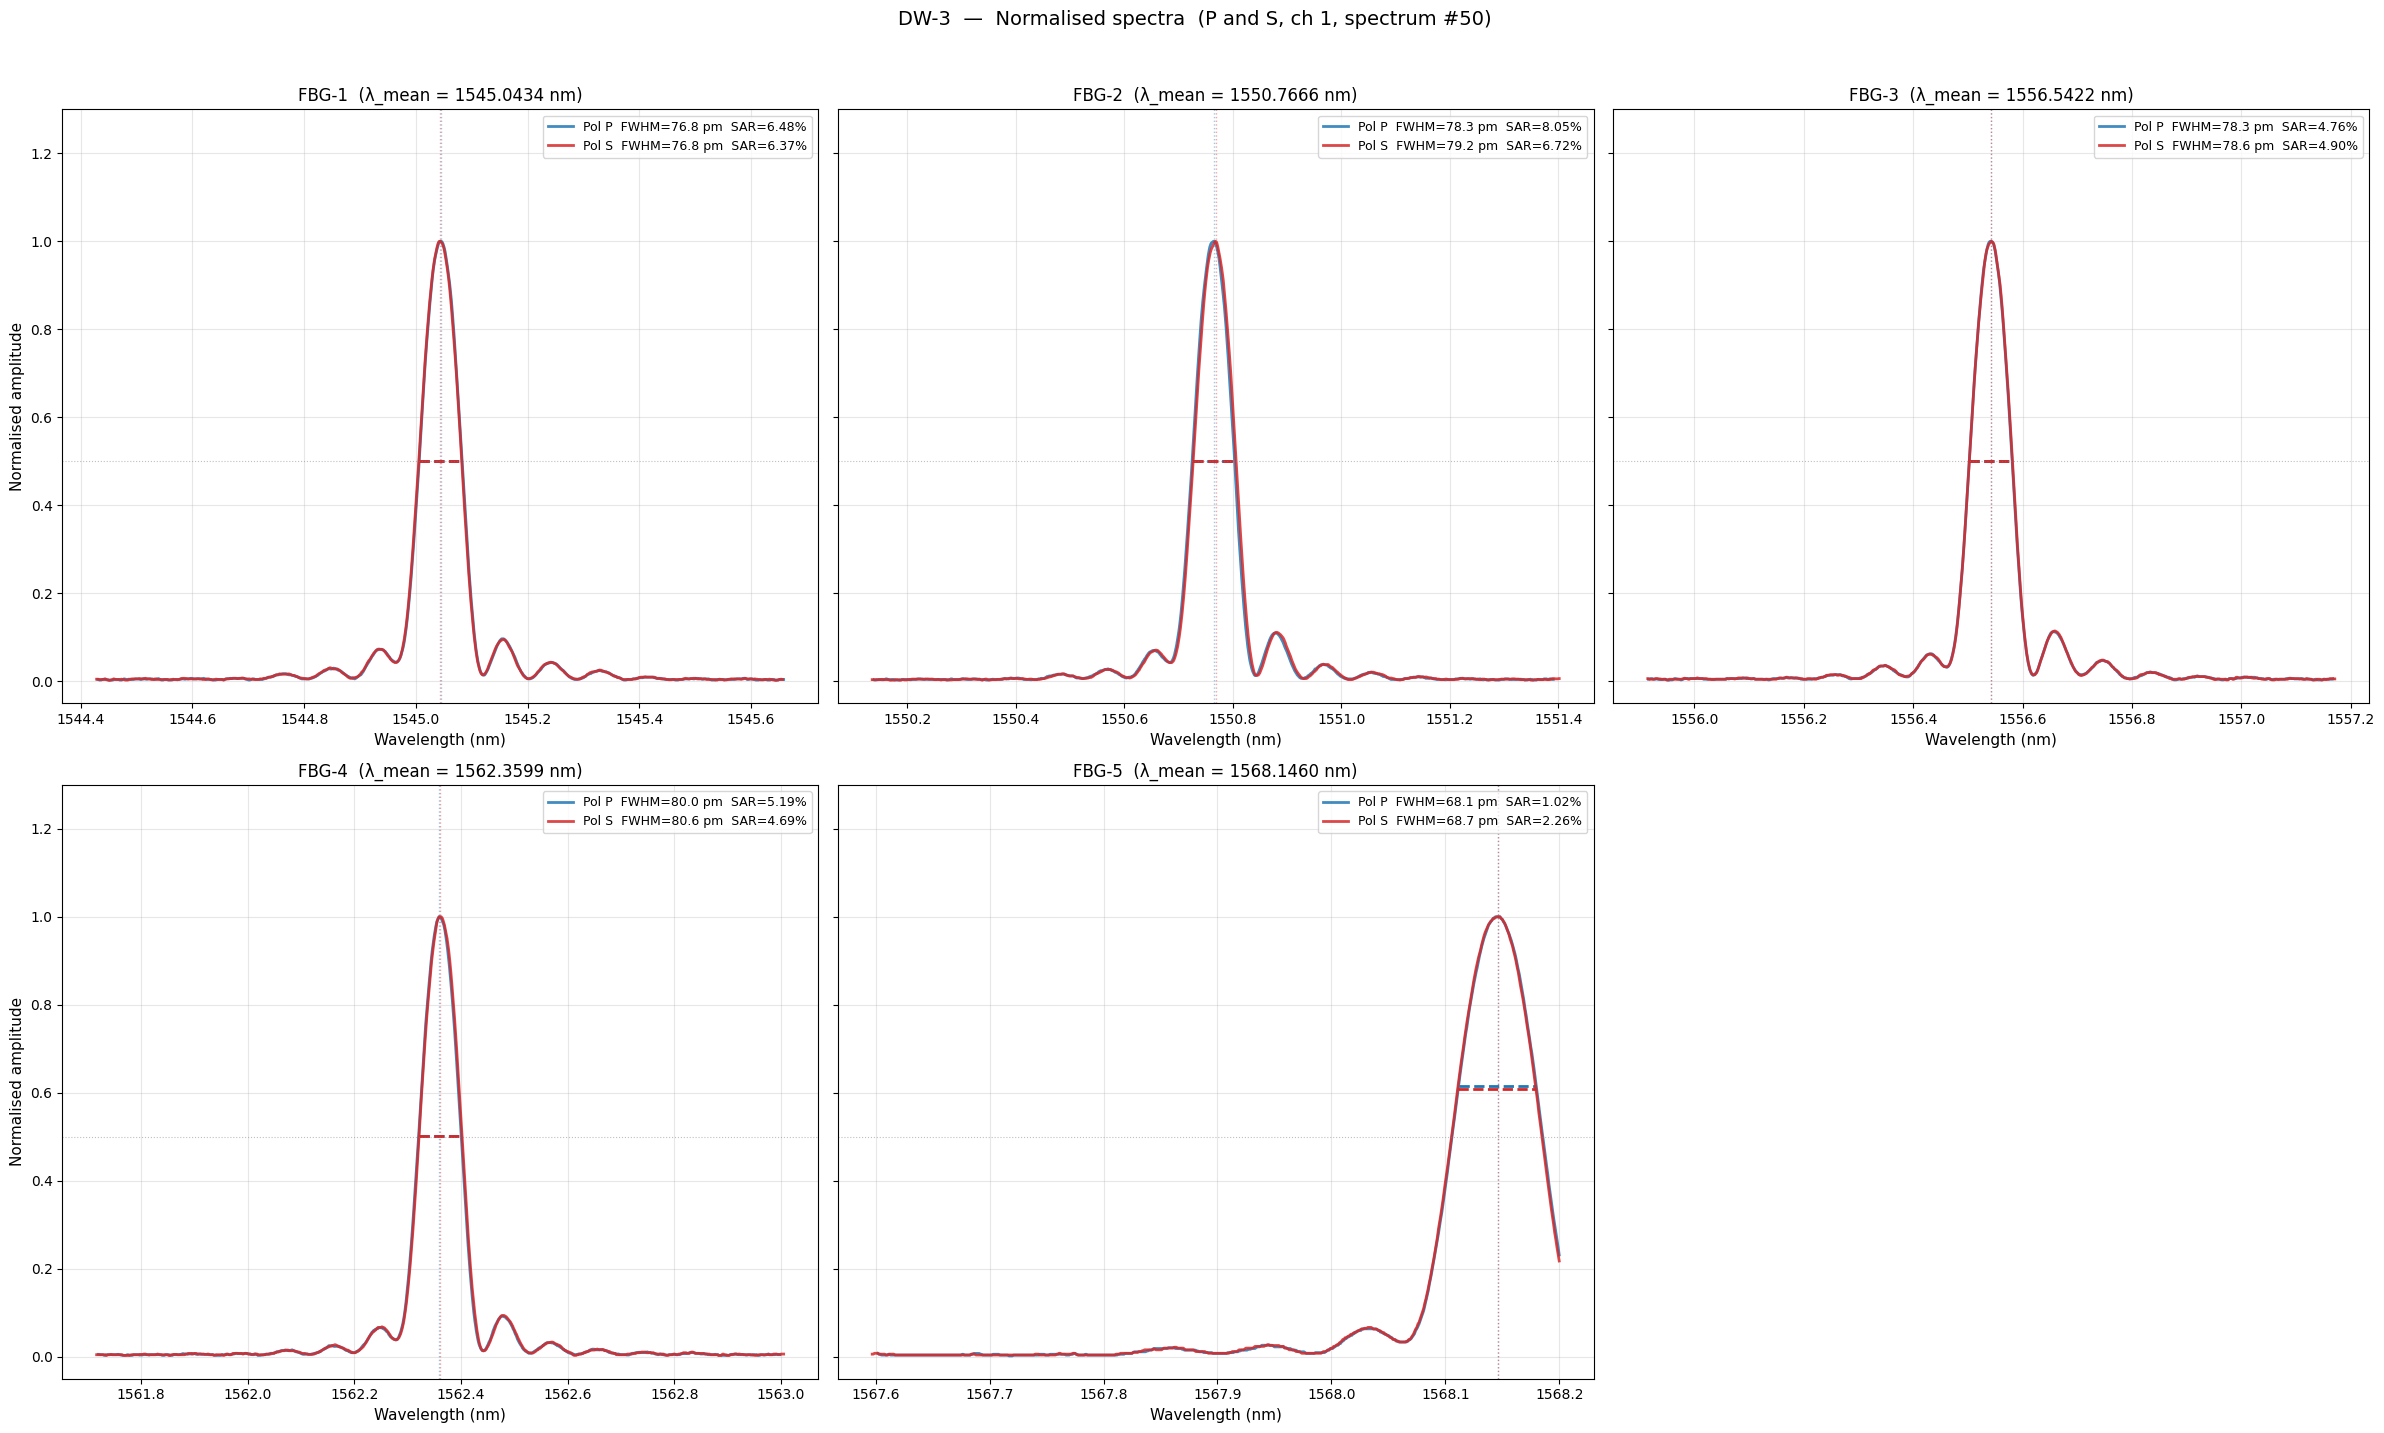

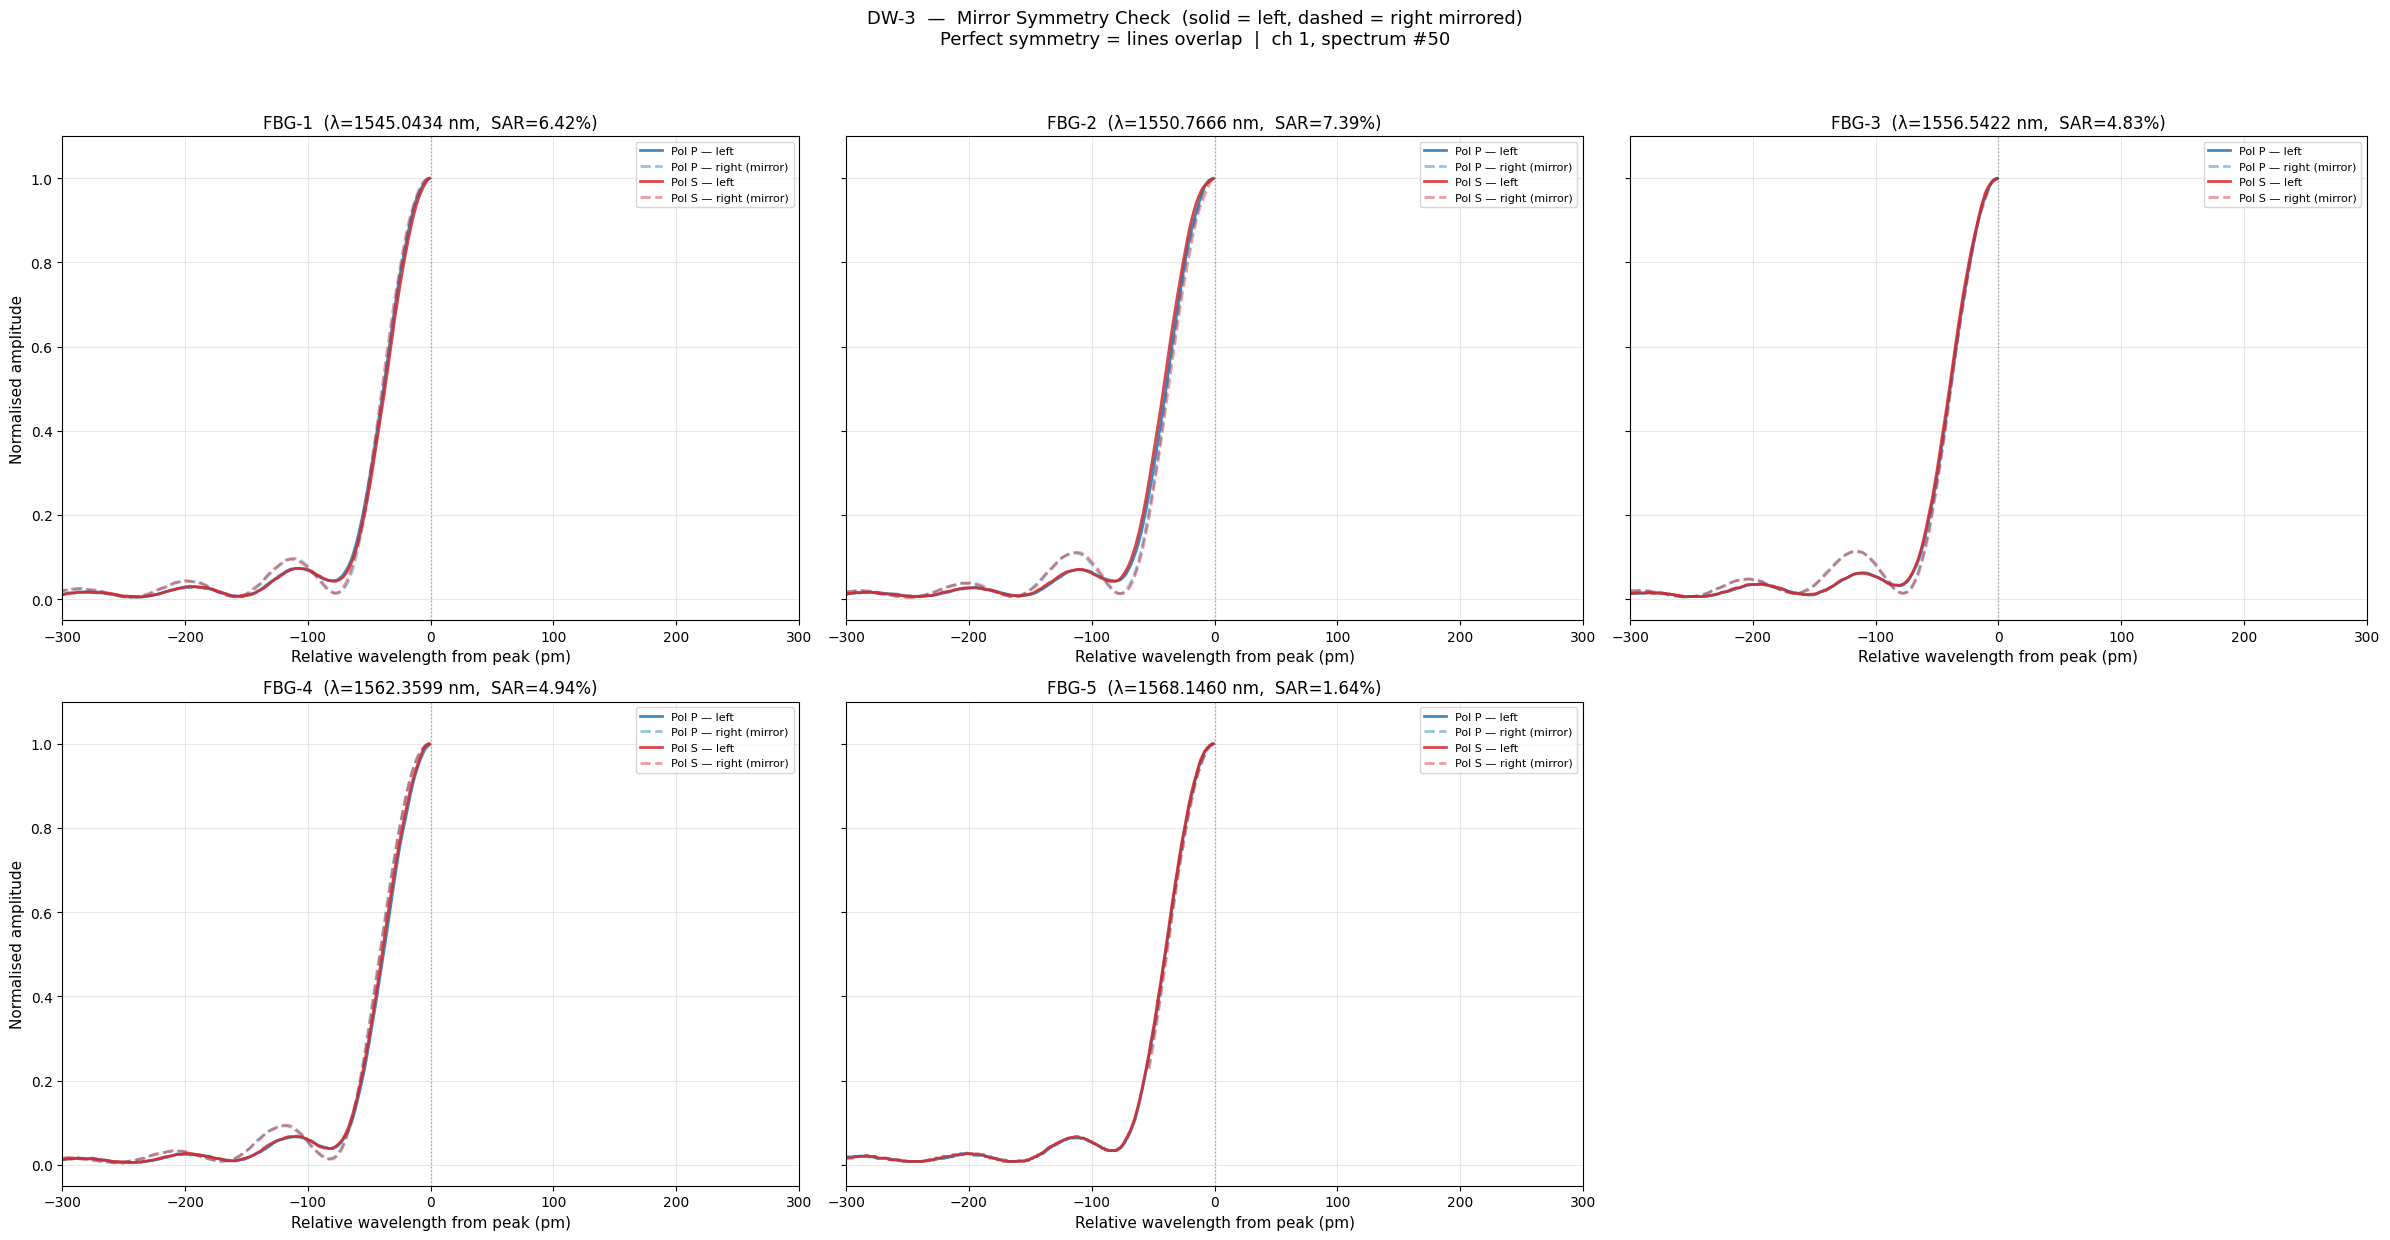

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# DW-3  —  Quality Analysis
#   · Channel 1, 5 FBG sensors  (DTG-A3C6-A00, Q-2023-0499-v2)
#   · Uses spectrum_wav and idx_espectro already loaded above
#   · Peak wavelength table  (P / S / mean)
#   · QC-1  Sensor spacing
#   · QC-2  FWHM < 100 pm
#   · QC-3  SLSR > 20 dB
#   · QC-4  Spectral Asymmetry Ratio  1–3 %
#   · QC-5  Design wavelength deviation
#   · FBG length estimate from FWHM
#   · Plots: normalised spectra + mirror symmetry per sensor
# ══════════════════════════════════════════════════════════════════════════════
from scipy.signal import find_peaks, peak_widths
import numpy as np, matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# Configuration  — reuse spectrum_wav and idx_espectro from the cell above
# ──────────────────────────────────────────────────────────────────────────────
CHANNEL_DW3    = 1           # DW-3 fibre → channel 1
N_SENSORS_DW3  = 5           # 5 FBG sensors (all DTGs from spec Q-2023-0499-v2)
LAM_START_DW3  = 1529.0      # nm
LAM_END_DW3    = 1568.2      # nm
N_POINTS_DW3   = 39200       # ≈ 1 pm/pt
FWHM_THRESH_PM = 100.0       # pm
SLSR_THRESH_DB =  20.0       # dB
ASYM_MIN_PCT   =   1.0       # %
ASYM_MAX_PCT   =   3.0       # %
N_GROUP_DW3    =   1.468     # effective group index SMF-28 @ 1550 nm
POL_LABELS     = {0: "P", 1: "S"}
COLORS_POL     = {0: "tab:blue", 1: "tab:red"}

# Design values from spec Q-2023-0499-v2 (DTG-A3C6-A00, Ormocer-T coating):
# 5 DTGs at 1545, 1550.8, 1556.6, 1562.4, 1568.2 nm — analysing first 4
DESIGN_SPACING_NM        = 5.8    # nm — steps of 5.8 nm between gratings
DESIGN_WAVELENGTHS_DW3   = [1545.0, 1550.8, 1556.6, 1562.4, 1568.2]  # nm (all 5)
DESIGN_GRATING_LENGTH_MM = 10.0   # mm — grating length from spec

# ──────────────────────────────────────────────────────────────────────────────
# Build wavelength axis and extract signals (uses already-loaded spectrum_wav)
# ──────────────────────────────────────────────────────────────────────────────
lam_dw3 = np.linspace(LAM_START_DW3, LAM_END_DW3, N_POINTS_DW3)
dlam_pm = (LAM_END_DW3 - LAM_START_DW3) / (N_POINTS_DW3 - 1) * 1e3  # pm/pt

print(f"✅ Using spectrum index : {idx_espectro}  (same as above)")
print(f"   Channel              : {CHANNEL_DW3}  (DW-3)")
print(f"   λ-axis               : {LAM_START_DW3}–{LAM_END_DW3} nm  "
      f"({N_POINTS_DW3} pts, Δλ = {dlam_pm:.3f} pm/pt)")
print(f"   Analysing            : {N_SENSORS_DW3} sensors (FBG-1 to FBG-{N_SENSORS_DW3}, all gratings)")

signals_dw3 = {
    0: spectrum_wav[idx_espectro, 0, CHANNEL_DW3, :],   # P polarisation
    1: spectrum_wav[idx_espectro, 1, CHANNEL_DW3, :],   # S polarisation
}

# ──────────────────────────────────────────────────────────────────────────────
# Helper functions
# ──────────────────────────────────────────────────────────────────────────────
def find_n_peaks_dw3(signal, n=N_SENSORS_DW3, min_dist_nm=2.0,
                     min_prom_frac=0.10, min_h_frac=0.05):
    min_dist_pts = max(int(min_dist_nm / (dlam_pm * 1e-3)), 10)
    sig_max = np.max(signal)
    pks, props = find_peaks(
        signal,
        height=sig_max * min_h_frac,
        prominence=sig_max * min_prom_frac,
        distance=min_dist_pts,
    )
    if len(pks) == 0:
        return []
    if len(pks) <= n:
        return sorted(pks.tolist())
    proms   = props.get("prominences", np.ones(len(pks)))
    top_idx = np.argsort(proms)[::-1][:n]
    return sorted(pks[top_idx].tolist())

def compute_slsr_dw3(signal, peak_idx, inner_guard_nm=0.3, outer_guard_nm=1.5):
    """20·log10(main_peak / max_sidelobe) [dB] — annular search region."""
    inner_pts = max(int(inner_guard_nm / (dlam_pm * 1e-3)), 1)
    outer_pts = max(int(outer_guard_nm / (dlam_pm * 1e-3)), 1)
    mask = np.zeros(len(signal), dtype=bool)
    mask[max(0, peak_idx - outer_pts):max(0, peak_idx - inner_pts)] = True
    mask[min(len(signal), peak_idx + inner_pts + 1):min(len(signal), peak_idx + outer_pts + 1)] = True
    if not mask.any():
        return np.inf
    sl_max = np.max(signal[mask])
    if sl_max <= 0:
        return np.inf
    return 20.0 * np.log10(signal[peak_idx] / sl_max)

def compute_asymmetry_50_10_dw3(signal, peak_idx):
    """SAR via 50%-10% width method: A = |W_L - W_R| / (W_L + W_R) × 100%."""
    try:
        _, _, l50, r50 = peak_widths(signal, [peak_idx], rel_height=0.5)
        _, _, l10, r10 = peak_widths(signal, [peak_idx], rel_height=0.9)
        W_L = abs(l50[0] - l10[0])
        W_R = abs(r10[0] - r50[0])
        tot = W_L + W_R
        return 100.0 * abs(W_L - W_R) / tot if tot > 0 else np.nan
    except Exception:
        return np.nan

def compute_asymmetry_fwhm_dw3(peak_idx, left_ip, right_ip):
    dl_l = (peak_idx - left_ip)  * dlam_pm
    dl_r = (right_ip - peak_idx) * dlam_pm
    tot  = dl_l + dl_r
    return 100.0 * abs(dl_r - dl_l) / tot if tot > 0 else np.nan

def compute_mirror_corr_dw3(signal, peak_idx, window_pts=200):
    i0, i1 = max(0, peak_idx - window_pts), min(len(signal), peak_idx + window_pts + 1)
    L, R   = signal[i0:peak_idx], signal[peak_idx + 1:i1]
    n      = min(len(L), len(R))
    if n < 10:
        return np.nan
    L, R = L[-n:], R[:n][::-1]
    Ln = (L - L.min()) / (L.max() - L.min() + 1e-10)
    Rn = (R - R.min()) / (R.max() - R.min() + 1e-10)
    return 100.0 * (1.0 - np.corrcoef(Ln, Rn)[0, 1])

# ──────────────────────────────────────────────────────────────────────────────
# Detect peaks and compute all metrics
# ──────────────────────────────────────────────────────────────────────────────
peaks_found_dw3 = {pol: find_n_peaks_dw3(signals_dw3[pol]) for pol in range(2)}
print(f"\n🔍 DW-3 peaks detected (ch {CHANNEL_DW3}, spectrum #{idx_espectro}):")
for pol, pname in POL_LABELS.items():
    print(f"   Pol {pname}: {[f'{lam_dw3[p]:.4f} nm' for p in peaks_found_dw3[pol]]}")

metrics_dw3 = {}
for pol in range(2):
    sig, pks = signals_dw3[pol], peaks_found_dw3[pol]
    for s_idx in range(N_SENSORS_DW3):
        key = (s_idx + 1, pol)
        if s_idx >= len(pks):
            metrics_dw3[key] = None
            continue
        pk = pks[s_idx]
        w, wh, li, ri = peak_widths(sig, [pk], rel_height=0.5)
        metrics_dw3[key] = {
            "pk_idx"         : pk,
            "lambda_nm"      : lam_dw3[pk],
            "fwhm_pm"        : w[0] * dlam_pm,
            "slsr_db"        : compute_slsr_dw3(sig, pk),
            "asym_50_10_pct" : compute_asymmetry_50_10_dw3(sig, pk),
            "asym_fwhm_pct"  : compute_asymmetry_fwhm_dw3(pk, li[0], ri[0]),
            "asym_mirror_pct": compute_mirror_corr_dw3(sig, pk, window_pts=300),
            "left_ip"        : li[0],
            "right_ip"       : ri[0],
            "w_height"       : wh[0],
        }

# ──────────────────────────────────────────────────────────────────────────────
# Peak Wavelength Table
# ──────────────────────────────────────────────────────────────────────────────
SEP = "═" * 70
sep = "─" * 70
print(f"\n{SEP}")
print(f"  DW-3  —  Peak Wavelengths   (ch {CHANNEL_DW3}, spectrum #{idx_espectro})")
print(SEP)
print(f"  {'Sensor':<10}  {'λ_P (nm)':>13}  {'λ_S (nm)':>13}  {'λ_mean (nm)':>14}")
print(f"  {'-'*58}")

lambda_means_dw3 = []
for s in range(1, N_SENSORS_DW3 + 1):
    rP = metrics_dw3.get((s, 0))
    rS = metrics_dw3.get((s, 1))
    lP = f"{rP['lambda_nm']:.5f}" if rP else "N/A"
    lS = f"{rS['lambda_nm']:.5f}" if rS else "N/A"
    lm = None
    if rP and rS:   lm = (rP["lambda_nm"] + rS["lambda_nm"]) / 2.0
    elif rP:        lm = rP["lambda_nm"]
    elif rS:        lm = rS["lambda_nm"]
    lambda_means_dw3.append(lm)
    lM = f"{lm:.5f}" if lm else "N/A"
    print(f"  FBG-{s}       {lP:>13}  {lS:>13}  {lM:>14}")
print(SEP)

# ──────────────────────────────────────────────────────────────────────────────
# QC-1  Sensor Spacing
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-1  Sensor Spacing Uniformity")
print(f"        (pass if |Δλ_measured − {DESIGN_SPACING_NM:.3f} nm| < 0.050 nm)")
print(sep)
print(f"  {'Adjacent Pair':<20}  {'Δλ_meas (nm)':>14}  {'Δλ_meas (pm)':>14}  {'|Δ−design| (nm)':>17}  {'|Δ−design| (pm)':>17}  {'Result':>10}")
print(f"  {'-'*105}")

valid_lms_dw3 = [(i + 1, lm) for i, lm in enumerate(lambda_means_dw3) if lm is not None]
if len(valid_lms_dw3) >= 2:
    spacing_thresh = 0.050  # nm
    all_pass_qc1 = True
    for i, sp in enumerate(np.diff([v[1] for v in valid_lms_dw3])):
        s1, s2 = valid_lms_dw3[i][0], valid_lms_dw3[i + 1][0]
        pair_label = f"FBG-{s1} → FBG-{s2}"
        delta  = abs(sp - DESIGN_SPACING_NM)
        ok     = delta < spacing_thresh
        result = "✅ PASS" if ok else "❌ FAIL"
        if not ok: all_pass_qc1 = False
        print(f"  {pair_label:<20}  {sp:>14.5f}  {sp*1e3:>14.2f}  {delta:>17.5f}  {delta*1e3:>17.2f}  {result:>10}")
    print(f"\n  Overall QC-1: {'✅ ALL PASS' if all_pass_qc1 else '❌ SOME FAIL'}")
else:
    print("  ⚠️  Not enough valid peaks.")

# ──────────────────────────────────────────────────────────────────────────────
# QC-2  FWHM < 100 pm
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-2  FWHM   (pass if < {FWHM_THRESH_PM:.0f} pm)")
print(sep)
print(f"  {'Sensor':<10} {'Pol':<4}  {'FWHM (pm)':>13}   Result")
print(f"  {'-'*50}")
for s in range(1, N_SENSORS_DW3 + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics_dw3.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>13}")
            continue
        ok = r["fwhm_pm"] < FWHM_THRESH_PM
        print(f"  FBG-{s}      {pname:<4}  {r['fwhm_pm']:>13.1f}   {'✅ PASS' if ok else '❌ FAIL'}")

# ──────────────────────────────────────────────────────────────────────────────
# QC-3  SLSR > 20 dB
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-3  SLSR   (pass if > {SLSR_THRESH_DB:.0f} dB)")
print(sep)
print(f"  {'Sensor':<10} {'Pol':<4}  {'SLSR (dB)':>13}   Result")
print(f"  {'-'*50}")
for s in range(1, N_SENSORS_DW3 + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics_dw3.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>13}")
            continue
        ok = r["slsr_db"] > SLSR_THRESH_DB
        print(f"  FBG-{s}      {pname:<4}  {r['slsr_db']:>13.1f}   {'✅ PASS' if ok else '❌ FAIL'}")

# ──────────────────────────────────────────────────────────────────────────────
# QC-4  Spectral Asymmetry Ratio  1–3 %
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-4  Spectral Asymmetry Ratio (50-10% method)   (pass if {ASYM_MIN_PCT}–{ASYM_MAX_PCT} %)")
print(sep)
print(f"  {'Sensor':<10} {'Pol':<4}  {'SAR_50-10':>11}   Result")
print(f"  {'-'*50}")
sar_summary_dw3 = {}
for s in range(1, N_SENSORS_DW3 + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics_dw3.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>11}")
            continue
        a50 = r["asym_50_10_pct"]
        sar_summary_dw3[(s, pol)] = a50
        if np.isnan(a50):
            flag = "⚠️  N/A"
        elif ASYM_MIN_PCT <= a50 <= ASYM_MAX_PCT:
            flag = "✅ PASS"
        else:
            flag = f"❌ FAIL  ({'too symmetric' if a50 < ASYM_MIN_PCT else 'too asymmetric'})"
        print(f"  FBG-{s}      {pname:<4}  {a50:>10.2f}%   {flag}")
print(f"\n  💡 SAR_50-10: A = |W_L − W_R| / (W_L + W_R) × 100%")

# ──────────────────────────────────────────────────────────────────────────────
# QC-5  Design Wavelength Deviation
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{sep}")
print(f"  QC-5  Design Wavelength Deviation   (pass if < 0.050 nm)")
print(sep)
print(f"  {'Sensor':<10}  {'λ_design (nm)':>15}  {'λ_mean (nm)':>15}  {'Δλ (nm)':>12}   Result")
print(f"  {'-'*75}")
design_thresh = 0.050  # nm
for s in range(1, N_SENSORS_DW3 + 1):
    lm = lambda_means_dw3[s - 1]
    ld = DESIGN_WAVELENGTHS_DW3[s - 1]
    lm_str = f"{lm:.5f}" if lm else "N/A"
    delta  = abs(lm - ld) if lm else None
    ok     = (delta < design_thresh) if delta is not None else False
    delta_str = f"{delta:.5f}" if delta is not None else "N/A"
    print(f"  FBG-{s}       {ld:>15.5f}  {lm_str:>15}  {delta_str:>12}   {'✅ PASS' if ok else '❌ FAIL'}")

# ──────────────────────────────────────────────────────────────────────────────
# FBG Length Estimate from FWHM:  L ≈ λ_B² / (2 × n_g × FWHM)
# ──────────────────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print(f"  📏 DW-3  —  FBG Length Estimate   (n_g = {N_GROUP_DW3})")
print(SEP)
print(f"  {'Sensor':<10} {'Pol':<4}  {'λ_B (nm)':>12}  {'FWHM (pm)':>12}  {'L_est (mm)':>12}")
print(f"  {'-'*60}")
fbg_lengths_dw3 = {}
for s in range(1, N_SENSORS_DW3 + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics_dw3.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>12}  {'N/A':>12}  {'N/A':>12}")
            continue
        lb = r["lambda_nm"]
        fw = r["fwhm_pm"] / 1000.0  # nm
        L  = lb**2 / (2 * N_GROUP_DW3 * fw)
        fbg_lengths_dw3[(s, pol)] = L
        print(f"  FBG-{s}      {pname:<4}  {lb:>12.4f}  {r['fwhm_pm']:>12.1f}  {L:>12.2f}")

print(f"\n  RESUMEN (promedio P+S)")
print(f"  {'-'*60}")
print(f"  {'Sensor':<10}  {'<λ_B> (nm)':>13}  {'<FWHM> (pm)':>14}  {'<L_est> (mm)':>14}")
print(f"  {'-'*60}")
for s in range(1, N_SENSORS_DW3 + 1):
    rP, rS = metrics_dw3.get((s, 0)), metrics_dw3.get((s, 1))
    if rP and rS:
        lm_avg  = (rP["lambda_nm"] + rS["lambda_nm"]) / 2
        fwm_avg = (rP["fwhm_pm"]   + rS["fwhm_pm"])   / 2
        Lm_avg  = (fbg_lengths_dw3.get((s, 0), np.nan) + fbg_lengths_dw3.get((s, 1), np.nan)) / 2
        print(f"  FBG-{s}       {lm_avg:>13.4f}  {fwm_avg:>14.1f}  {Lm_avg:>14.2f}")
print(SEP)
print(f"\n  📐 Design grating length (spec Q-2023-0499): {DESIGN_GRATING_LENGTH_MM:.1f} mm")
print(f"     → L_est should be ≈ {DESIGN_GRATING_LENGTH_MM:.1f} mm for well-manufactured FBGs")

# ──────────────────────────────────────────────────────────────────────────────
# Plot 1 — Normalised spectra per sensor, P and S superposed  (2×2 grid)
# ──────────────────────────────────────────────────────────────────────────────
_ncols_p1 = int(np.ceil(N_SENSORS_DW3 / 2))
_nrows_p1 = 2 if N_SENSORS_DW3 > _ncols_p1 else 1
fig, axes = plt.subplots(_nrows_p1, _ncols_p1,
                         figsize=(8 * _ncols_p1, 7 * _nrows_p1),
                         sharey=True, squeeze=False)
axes = axes.flatten()
for _ax in axes[N_SENSORS_DW3:]:
    _ax.set_visible(False)

for s_idx, ax in enumerate(axes[:N_SENSORS_DW3]):
    s = s_idx + 1
    plotted = False
    for pol, pname in POL_LABELS.items():
        r   = metrics_dw3.get((s, pol))
        if r is None:
            continue
        sig = signals_dw3[pol]
        pk  = r["pk_idx"]
        if sig[pk] == 0:
            continue
        fwhm_pts  = r["fwhm_pm"] / dlam_pm
        zoom      = max(int(fwhm_pts * 8), 60)
        i0, i1    = max(0, pk - zoom), min(len(sig), pk + zoom + 1)
        lam_zoom  = lam_dw3[i0:i1]
        y_norm    = sig[i0:i1] / sig[pk]
        w_h_norm  = r["w_height"] / sig[pk]
        lam_left  = np.interp(r["left_ip"],  np.arange(len(lam_dw3)), lam_dw3)
        lam_right = np.interp(r["right_ip"], np.arange(len(lam_dw3)), lam_dw3)
        color = COLORS_POL[pol]
        ax.plot(lam_zoom, y_norm, color=color, linewidth=2.0, alpha=0.85,
                label=f"Pol {pname}  FWHM={r['fwhm_pm']:.1f} pm  SAR={r['asym_50_10_pct']:.2f}%")
        ax.hlines(w_h_norm, lam_left, lam_right, color=color, linestyle="--", linewidth=2.0)
        ax.axvline(lam_dw3[pk], color=color, linestyle=":", linewidth=1.0, alpha=0.4)
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "No peak found", transform=ax.transAxes, ha="center", va="center")
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)
    lm = lambda_means_dw3[s_idx]
    lm_str = f"λ_mean = {lm:.4f} nm" if lm else "λ_mean = N/A"
    ax.set_title(f"FBG-{s}  ({lm_str})", fontsize=12)
    ax.set_xlabel("Wavelength (nm)", fontsize=11)
    if s_idx % _ncols_p1 == 0:
        ax.set_ylabel("Normalised amplitude", fontsize=11)
    ax.set_ylim(-0.05, 1.30)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle(
    f"DW-3  —  Normalised spectra  (P and S, ch {CHANNEL_DW3}, spectrum #{idx_espectro})",
    fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Plot 2 — Mirror symmetry check per sensor  (2×2 grid)
# ──────────────────────────────────────────────────────────────────────────────
_ncols_p2 = int(np.ceil(N_SENSORS_DW3 / 2))
_nrows_p2 = 2 if N_SENSORS_DW3 > _ncols_p2 else 1
fig2, axes2 = plt.subplots(_nrows_p2, _ncols_p2,
                            figsize=(8 * _ncols_p2, 6 * _nrows_p2),
                            sharey=True, squeeze=False)
axes2 = axes2.flatten()
for _ax in axes2[N_SENSORS_DW3:]:
    _ax.set_visible(False)

for s_idx, ax in enumerate(axes2[:N_SENSORS_DW3]):
    s = s_idx + 1
    plotted = False
    for pol, pname in POL_LABELS.items():
        r   = metrics_dw3.get((s, pol))
        if r is None:
            continue
        sig = signals_dw3[pol]
        pk  = r["pk_idx"]
        if sig[pk] == 0:
            continue
        wpts  = 300
        i0, i1 = max(0, pk - wpts), min(len(sig), pk + wpts + 1)
        L_idx  = np.arange(i0, pk)
        R_idx  = np.arange(pk + 1, i1)
        L_rel  = (lam_dw3[L_idx] - lam_dw3[pk]) * 1e3   # pm
        R_rel  = (lam_dw3[R_idx] - lam_dw3[pk]) * 1e3   # pm
        Ln     = sig[i0:pk]    / sig[pk]
        Rn     = sig[pk+1:i1]  / sig[pk]
        color  = COLORS_POL[pol]
        ax.plot(L_rel, Ln, color=color, linewidth=2.0, alpha=0.85,
                label=f"Pol {pname} — left")
        ax.plot(-R_rel, Rn, color=color, linewidth=2.0, alpha=0.45,
                linestyle="--", label=f"Pol {pname} — right (mirror)")
        plotted = True
    if not plotted:
        ax.text(0.5, 0.5, "No peak found", transform=ax.transAxes, ha="center", va="center")
    lm        = lambda_means_dw3[s_idx]
    sar_vals  = [sar_summary_dw3.get((s, p), np.nan) for p in range(2)]
    sar_m     = np.nanmean(sar_vals)
    lm_str    = f"λ={lm:.4f} nm" if lm else "λ=N/A"
    sar_str   = f"SAR={sar_m:.2f}%" if not np.isnan(sar_m) else "SAR=N/A"
    ax.set_title(f"FBG-{s}  ({lm_str},  {sar_str})", fontsize=12)
    ax.set_xlabel("Relative wavelength from peak (pm)", fontsize=11)
    if s_idx % _ncols_p2 == 0:
        ax.set_ylabel("Normalised amplitude", fontsize=11)
    ax.axvline(0, color="black", linestyle=":", linewidth=1.0, alpha=0.3)
    ax.set_xlim(-300, 300)
    ax.set_ylim(-0.05, 1.10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle(
    f"DW-3  —  Mirror Symmetry Check  (solid = left, dashed = right mirrored)\n"
    f"Perfect symmetry = lines overlap  |  ch {CHANNEL_DW3}, spectrum #{idx_espectro}",
    fontsize=13, y=1.03)
plt.tight_layout()
plt.show()



═════════════════════════════════════════════════════════════════════════════════════
  DW-3  —  Peak Reflectivity   (ch 1, spectrum #50)
  R_dB = 10·log₁₀(peak / local_baseline)  |  local baseline = valley min in ±5 nm (excl. ±1.5 nm core)
═════════════════════════════════════════════════════════════════════════════════════
  Sensor     Pol         Peak   Baseline(loc)     Ratio    R_dB(loc)    R_dB(glob)   Result
  ------------------------------------------------------------------------------------------
  FBG-1      P         1514.0            2.00     757.0         28.8          28.8   ❌ FAIL
  FBG-1      S         1508.0            2.00     754.0         28.8          28.8   ❌ FAIL
  FBG-2      P         1502.0            2.00     751.0         28.8          28.8   ❌ FAIL
  FBG-2      S         1656.0            2.00     828.0         29.2          29.2   ❌ FAIL
  FBG-3      P         1329.0            2.00     664.5         28.2          28.2   ❌ FAIL
  FBG-3      S         1332

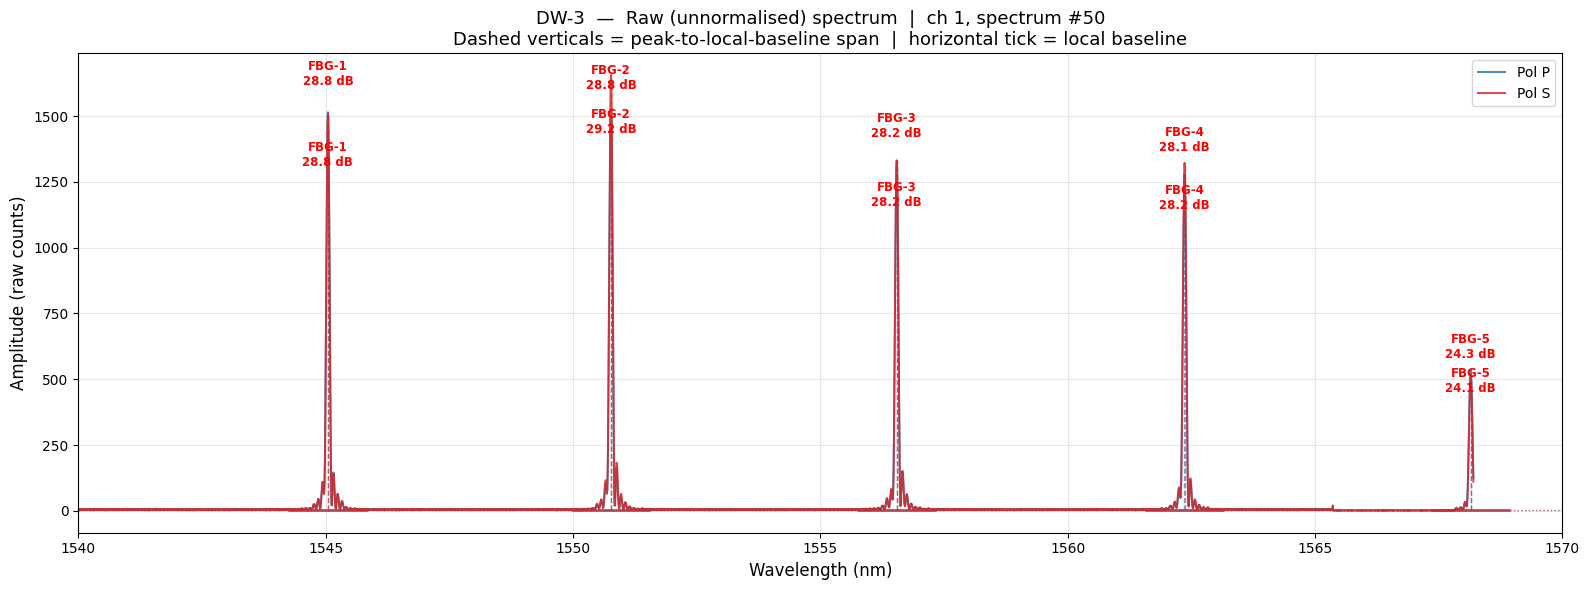

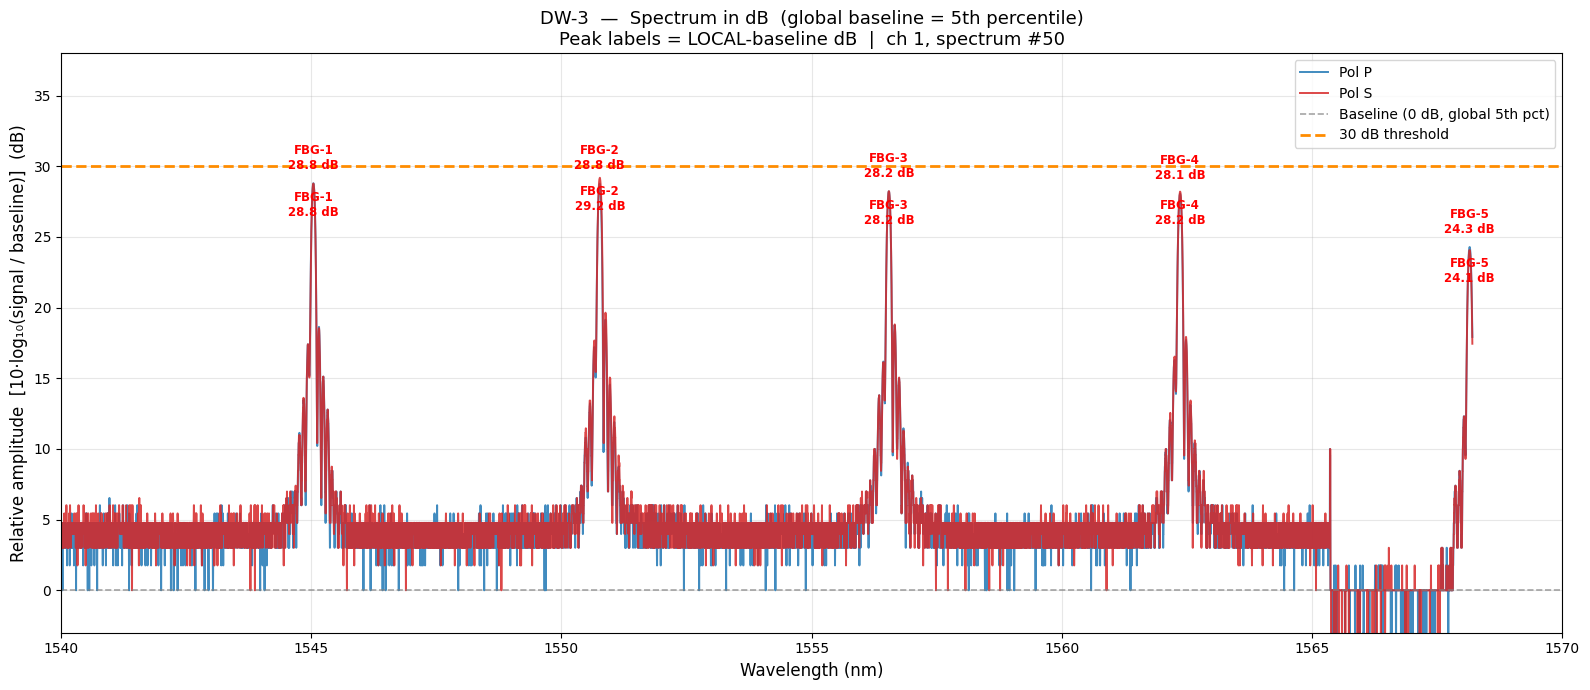

In [14]:

# ══════════════════════════════════════════════════════════════════════════════
# DW-3  —  Peak Reflectivity  (unnormalised spectrum, linear → dB)
#
#   R_dB = 10·log₁₀( peak_amplitude / baseline )
#
#   Baseline strategy:
#     · Global  : 5th percentile of the full spectrum (robust noise floor)
#     · Local   : valley minimum in ±5 nm around the grating (excl. ±1.5 nm
#                 core), falling back to global if the valley touches zero
#   Both are shown; LOCAL baseline is used for the final pass/fail value.
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np, matplotlib.pyplot as plt

REFLECTIVITY_THRESH_DB = 30.0   # dB  — pass criterion

# ──────────────────────────────────────────────────────────────────────────────
# Baseline helpers
# ──────────────────────────────────────────────────────────────────────────────
def global_baseline(signal, pct=5):
    """Global noise floor: p-th percentile of the full spectrum."""
    return float(np.percentile(signal, pct))

def local_baseline(signal, peak_idx, half_window_nm=5.0, guard_nm=1.5):
    """
    Valley minimum in a window around the peak, excluding the inner ±guard_nm
    region (the grating itself).  Falls back to global baseline if the valley
    contains zeros (spectrum edge or completely empty window).
    """
    hw  = max(int(half_window_nm / (dlam_pm * 1e-3)), 1)
    grd = max(int(guard_nm       / (dlam_pm * 1e-3)), 1)
    i0  = max(0,           peak_idx - hw)
    i1  = min(len(signal), peak_idx + hw + 1)
    mask = np.ones(i1 - i0, dtype=bool)
    inner_start = max(0,        peak_idx - grd) - i0
    inner_end   = min(i1 - i0,  peak_idx + grd + 1 - i0)
    mask[inner_start:inner_end] = False
    gb = global_baseline(signal)
    if not mask.any():
        return gb
    local_min = float(np.min(signal[i0:i1][mask]))
    # if valley touches zero (spectrum edge), use global noise floor instead
    return local_min if local_min > 0 else gb

# ──────────────────────────────────────────────────────────────────────────────
# Compute reflectivity per sensor / polarisation
# ──────────────────────────────────────────────────────────────────────────────
SEP_R = "═" * 85
sep_r = "─" * 85

refl_results_dw3 = {}   # (sensor, pol) → R_dB (local baseline)

print(f"\n{SEP_R}")
print(f"  DW-3  —  Peak Reflectivity   (ch {CHANNEL_DW3}, spectrum #{idx_espectro})")
print(f"  R_dB = 10·log₁₀(peak / local_baseline)  |  local baseline = valley min in ±5 nm (excl. ±1.5 nm core)")
print(SEP_R)
print(f"  {'Sensor':<10} {'Pol':<4}  {'Peak':>10}  {'Baseline(loc)':>14}  {'Ratio':>8}  "
      f"{'R_dB(loc)':>11}  {'R_dB(glob)':>12}   Result")
print(f"  {'-'*90}")

for s in range(1, N_SENSORS_DW3 + 1):
    for pol, pname in POL_LABELS.items():
        r   = metrics_dw3.get((s, pol))
        sig = signals_dw3[pol]
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>10}")
            continue
        pk_val  = float(sig[r["pk_idx"]])
        bl_loc  = local_baseline(sig,  r["pk_idx"])
        bl_glob = global_baseline(sig)
        r_loc   = 10.0 * np.log10(pk_val / bl_loc)  if bl_loc  > 0 else np.nan
        r_glob  = 10.0 * np.log10(pk_val / bl_glob) if bl_glob > 0 else np.nan
        refl_results_dw3[(s, pol)] = r_loc
        ok   = (not np.isnan(r_loc)) and (r_loc >= REFLECTIVITY_THRESH_DB)
        flag = "✅ PASS" if ok else "❌ FAIL"
        ratio_str  = f"{pk_val/bl_loc:>8.1f}" if bl_loc > 0 else f"{'—':>8}"
        r_loc_str  = f"{r_loc:>11.1f}"  if not np.isnan(r_loc)  else f"{'N/A':>11}"
        r_glob_str = f"{r_glob:>12.1f}" if not np.isnan(r_glob) else f"{'N/A':>12}"
        print(f"  FBG-{s}      {pname:<4}  {pk_val:>10.1f}  {bl_loc:>14.2f}  "
              f"{ratio_str}  {r_loc_str}  {r_glob_str}   {flag}")

print(f"\n  Threshold: {REFLECTIVITY_THRESH_DB:.0f} dB")
print(SEP_R)

# ──────────────────────────────────────────────────────────────────────────────
# Plot A — Raw (linear, unnormalised) spectrum  |  DW-3 window zoom
# ──────────────────────────────────────────────────────────────────────────────
LAM_ZOOM0 = 1540.0
LAM_ZOOM1 = 1570.0

fig, ax = plt.subplots(figsize=(16, 6))
mask_zoom = (lam_dw3 >= LAM_ZOOM0) & (lam_dw3 <= LAM_ZOOM1)

for pol, pname in POL_LABELS.items():
    sig = signals_dw3[pol]
    col = COLORS_POL[pol]
    bl  = global_baseline(sig)

    ax.plot(lam_dw3[mask_zoom], sig[mask_zoom],
            color=col, linewidth=1.4, alpha=0.85, label=f"Pol {pname}")
    ax.axhline(bl, color=col, linestyle=":", linewidth=1.0, alpha=0.5)

    for s in range(1, N_SENSORS_DW3 + 1):
        r = metrics_dw3.get((s, pol))
        if r is None:
            continue
        pk_val  = float(sig[r["pk_idx"]])
        bl_loc  = local_baseline(sig, r["pk_idx"])
        r_db    = refl_results_dw3.get((s, pol), np.nan)
        lam_pk  = float(lam_dw3[r["pk_idx"]])

        ax.vlines(lam_pk, bl_loc, pk_val,
                  color=col, linestyle="--", linewidth=1.0, alpha=0.6)
        ax.hlines(bl_loc, lam_pk - 0.8, lam_pk + 0.8,
                  color=col, linestyle="-", linewidth=1.8, alpha=0.7)

        ok_peak  = (not np.isnan(r_db)) and (r_db >= REFLECTIVITY_THRESH_DB)
        txt_col  = "green" if ok_peak else "red"
        y_offset = 0.06 * pk_val if pol == 0 else -0.14 * pk_val
        lbl      = f"FBG-{s}\n{r_db:.1f} dB" if not np.isnan(r_db) else f"FBG-{s}\nN/A"
        ax.text(lam_pk, pk_val + y_offset, lbl,
                ha="center", va="bottom", fontsize=8.5,
                color=txt_col, fontweight="bold")

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Amplitude (raw counts)", fontsize=12)
ax.set_xlim(LAM_ZOOM0, LAM_ZOOM1)
ax.set_title(
    f"DW-3  —  Raw (unnormalised) spectrum  |  ch {CHANNEL_DW3}, spectrum #{idx_espectro}\n"
    f"Dashed verticals = peak-to-local-baseline span  |  horizontal tick = local baseline",
    fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────────────────────────
# Plot B — Spectrum in dB  (10·log₁₀(signal / global_baseline))
# ──────────────────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(16, 7))

for pol, pname in POL_LABELS.items():
    sig = signals_dw3[pol]
    col = COLORS_POL[pol]
    bl  = global_baseline(sig)

    lam_z = lam_dw3[mask_zoom]
    sig_z = sig[mask_zoom]
    with np.errstate(divide="ignore", invalid="ignore"):
        sig_db = np.where(sig_z > 0, 10.0 * np.log10(sig_z / bl), np.nan)

    ax2.plot(lam_z, sig_db, color=col, linewidth=1.4, alpha=0.85, label=f"Pol {pname}")

    for s in range(1, N_SENSORS_DW3 + 1):
        r = metrics_dw3.get((s, pol))
        if r is None:
            continue
        r_db_local = refl_results_dw3.get((s, pol), np.nan)
        lam_pk     = float(lam_dw3[r["pk_idx"]])
        y_pk_db    = 10.0 * np.log10(float(sig[r["pk_idx"]]) / bl) if bl > 0 else np.nan
        if np.isnan(y_pk_db):
            continue
        ok_peak = (not np.isnan(r_db_local)) and (r_db_local >= REFLECTIVITY_THRESH_DB)
        txt_col = "green" if ok_peak else "red"
        y_off   = 0.8 if pol == 0 else -2.5
        lbl     = f"FBG-{s}\n{r_db_local:.1f} dB" if not np.isnan(r_db_local) else f"FBG-{s}\nN/A"
        ax2.text(lam_pk, y_pk_db + y_off, lbl,
                 ha="center", va="bottom", fontsize=8.5,
                 color=txt_col, fontweight="bold")

ax2.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
            label="Baseline (0 dB, global 5th pct)")
ax2.axhline(REFLECTIVITY_THRESH_DB, color="darkorange", linestyle="--", linewidth=2.0,
            label=f"{REFLECTIVITY_THRESH_DB:.0f} dB threshold")
ax2.set_xlabel("Wavelength (nm)", fontsize=12)
ax2.set_ylabel("Relative amplitude  [10·log₁₀(signal / baseline)]  (dB)", fontsize=12)
ax2.set_xlim(LAM_ZOOM0, LAM_ZOOM1)
ax2.set_ylim(-3, REFLECTIVITY_THRESH_DB + 8)
ax2.set_title(
    f"DW-3  —  Spectrum in dB  (global baseline = 5th percentile)\n"
    f"Peak labels = LOCAL-baseline dB  |  ch {CHANNEL_DW3}, spectrum #{idx_espectro}",
    fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


  FBG   Type   W_L(pm)   W_R(pm)   SAR(%)
──────────────────────────────────────────────────
    1   Mean     22.23     22.01     0.51
    1      P     22.13     21.93     0.45
    1      S     22.36     22.13     0.51
    2   Mean     22.77     22.71     0.14
    2      P     22.75     23.00     0.55
    2      S     22.77     22.85     0.18
    3   Mean     23.12     22.50     1.37
    3      P     22.96     22.52     0.97
    3      S     23.31     22.46     1.85
    4   Mean     23.57     23.10     1.00
    4      P     23.51     23.32     0.40
    4      S     23.68     22.95     1.56


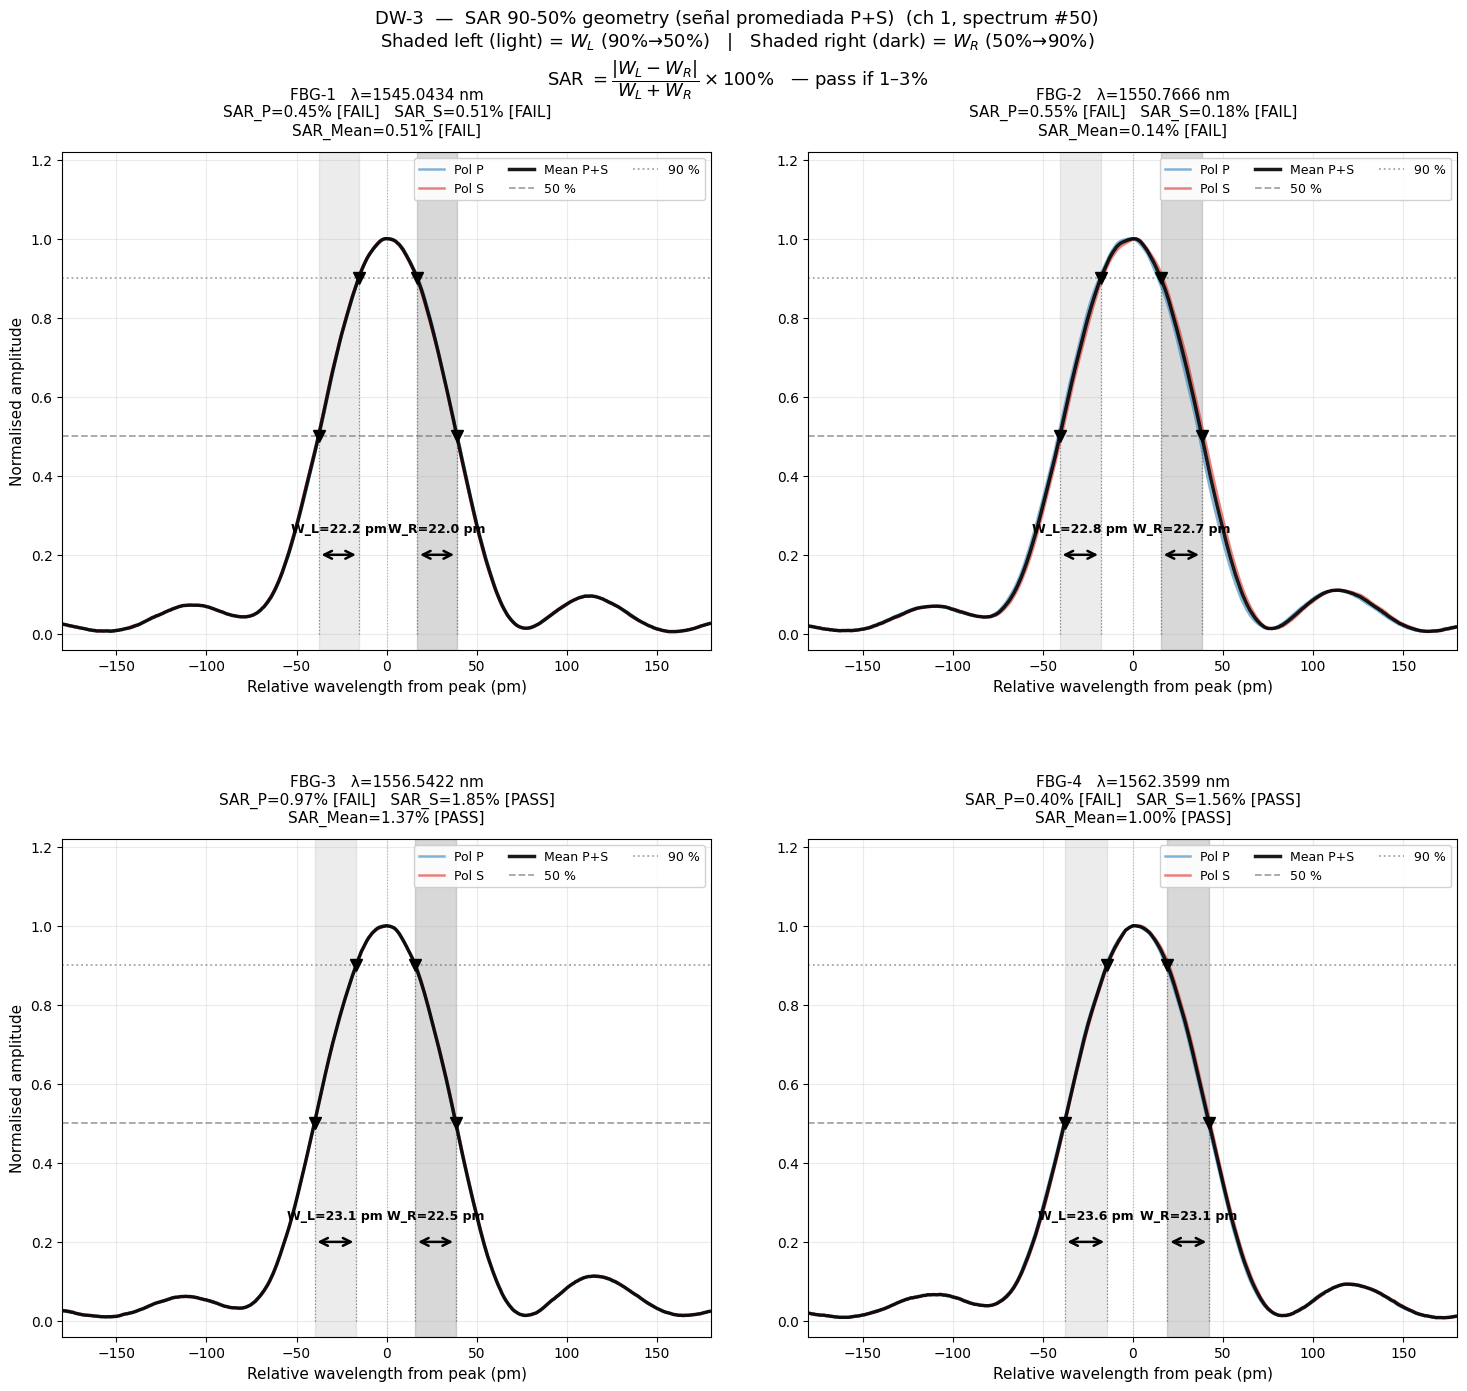

In [15]:

# ══════════════════════════════════════════════════════════════════════════════
# DW-3  —  SAR 90-50% geometry visualisation  (4 sensores)
#
#  Calcula SAR sobre la señal PROMEDIADA punto a punto entre ambas polarizaciones
#  Para eliminar efectos de birrefringencia y obtener la asimetría geométrica pura
# ══════════════════════════════════════════════════════════════════════════════
from scipy.signal import peak_widths, find_peaks
import numpy as np, matplotlib.pyplot as plt

ZOOM_PM = 180
N_PLOT  = min(4, N_SENSORS_DW3)

_ncols = 2
_nrows = 2
fig, axes = plt.subplots(_nrows, _ncols, figsize=(18, 15), squeeze=False)
axes = axes.flatten()
for _ax in axes[N_PLOT:]:
    _ax.set_visible(False)

def idx_to_pm(idx_float, lam_array, pk):
    lam_interp = np.interp(idx_float, np.arange(len(lam_array)), lam_dw3)
    return (lam_interp - lam_array[pk]) * 1e3

print(f"{'FBG':>5} {'Type':>6} {'W_L(pm)':>9} {'W_R(pm)':>9} {'SAR(%)':>8}")
print("─" * 50)

for s_idx, ax in enumerate(axes[:N_PLOT]):
    s = s_idx + 1
    
    # ── obtener métricas de ambas polarizaciones ──────────────────────────
    rP = metrics_dw3.get((s, 0))
    rS = metrics_dw3.get((s, 1))
    if rP is None or rS is None:
        continue
    
    sig_P = signals_dw3[0]
    sig_S = signals_dw3[1]
    pk_P  = rP["pk_idx"]
    pk_S  = rS["pk_idx"]
    
    # ── calcular señal promediada punto a punto ────────────────────────────
    sig_mean = (sig_P + sig_S) / 2.0
    
    # Detectar el pico en la señal promediada (región esperada)
    pk_guess = int((pk_P + pk_S) / 2)
    search_range = int(100 / dlam_pm)  # ±100 pm
    i_start = max(0, pk_guess - search_range)
    i_end = min(len(sig_mean), pk_guess + search_range)
    pk_mean = i_start + np.argmax(sig_mean[i_start:i_end])
    
    if sig_mean[pk_mean] == 0:
        print(f"{s:>5} {'Mean':>6}  -- zero peak --")
        continue
    
    # ── zoom window centrado en el pico promedio ───────────────────────────
    zoom_pts = max(int(ZOOM_PM / dlam_pm), 60)
    i0 = max(0, pk_mean - zoom_pts)
    i1 = min(len(sig_mean), pk_mean + zoom_pts + 1)
    lam_rel = (lam_dw3[i0:i1] - lam_dw3[pk_mean]) * 1e3
    
    # ── plotear las 3 señales normalizadas ────────────────────────────────
    y_P = sig_P[i0:i1] / sig_P[pk_P]
    y_S = sig_S[i0:i1] / sig_S[pk_S]
    y_M = sig_mean[i0:i1] / sig_mean[pk_mean]
    
    ax.plot(lam_rel, y_P, color='#3182bd', linewidth=1.8, alpha=0.6,
            label="Pol P", zorder=3)
    ax.plot(lam_rel, y_S, color='#de2d26', linewidth=1.8, alpha=0.6,
            label="Pol S", zorder=3)
    ax.plot(lam_rel, y_M, color='black', linewidth=2.5, alpha=0.9,
            label="Mean P+S", zorder=4)
    
    # ── calcular SAR sobre la señal promediada ─────────────────────────────
    try:
        _, _, l50_idx, r50_idx = peak_widths(sig_mean, [pk_mean], rel_height=0.5)
        _, _, l90_idx, r90_idx = peak_widths(sig_mean, [pk_mean], rel_height=0.1)
    except Exception as e:
        print(f"{s:>5} {'Mean':>6}  -- peak_widths failed: {e} --")
        continue
    
    l50_pm = idx_to_pm(l50_idx[0], lam_dw3, pk_mean)
    r50_pm = idx_to_pm(r50_idx[0], lam_dw3, pk_mean)
    l90_pm = idx_to_pm(l90_idx[0], lam_dw3, pk_mean)
    r90_pm = idx_to_pm(r90_idx[0], lam_dw3, pk_mean)
    
    W_L = abs(l50_pm - l90_pm)
    W_R = abs(r90_pm - r50_pm)
    tot = W_L + W_R
    sar_mean = 100.0 * abs(W_L - W_R) / tot if tot > 0 else np.nan
    
    print(f"{s:>5} {'Mean':>6} {W_L:>9.2f} {W_R:>9.2f} {sar_mean:>8.2f}")
    
    # ── calcular SAR individual para cada polarización ─────────────────────
    sar_vals = {}  # {pol: sar}
    for pol, pname, pk_pol, sig_pol, col in [
        (0, 'P', pk_P, sig_P, '#3182bd'),
        (1, 'S', pk_S, sig_S, '#de2d26')
    ]:
        try:
            _, _, l50, r50 = peak_widths(sig_pol, [pk_pol], rel_height=0.5)
            _, _, l90, r90 = peak_widths(sig_pol, [pk_pol], rel_height=0.1)
            l50p = idx_to_pm(l50[0], lam_dw3, pk_pol)
            r50p = idx_to_pm(r50[0], lam_dw3, pk_pol)
            l90p = idx_to_pm(l90[0], lam_dw3, pk_pol)
            r90p = idx_to_pm(r90[0], lam_dw3, pk_pol)
            wl = abs(l50p - l90p)
            wr = abs(r90p - r50p)
            sar_pol = 100.0 * abs(wl - wr) / (wl + wr) if (wl + wr) > 0 else np.nan
            sar_vals[pol] = sar_pol
            print(f"{s:>5} {pname:>6} {wl:>9.2f} {wr:>9.2f} {sar_pol:>8.2f}")
        except Exception as e:
            sar_vals[pol] = np.nan
            print(f"{s:>5} {pname:>6}  -- error: {e} --")
    
    # ── shading en señal promediada ────────────────────────────────────────
    ax.axvspan(l90_pm, l50_pm, alpha=0.15, color='gray', zorder=1)
    ax.axvspan(r50_pm, r90_pm, alpha=0.30, color='gray', zorder=1)
    
    # ── intersection markers ───────────────────────────────────────────────
    for xpm, ypct in [(l90_pm, 0.9), (l50_pm, 0.5),
                      (r50_pm, 0.5), (r90_pm, 0.9)]:
        ax.plot(xpm, ypct, marker='v', color='black',
                markersize=9, zorder=5, clip_on=False)
        ax.vlines(xpm, 0, ypct, color='black',
                  linestyle=':', linewidth=0.9, alpha=0.4, zorder=2)
    
    # ── double-headed arrows ───────────────────────────────────────────────
    y_arr = 0.20
    arrowprops = dict(arrowstyle='<->', color='black', lw=1.8, mutation_scale=14)
    
    ax.annotate('', xy=(l50_pm, y_arr), xytext=(l90_pm, y_arr),
                arrowprops=arrowprops, zorder=6)
    ax.text((l90_pm + l50_pm) / 2, y_arr + 0.05,
            f"W_L={W_L:.1f} pm", ha='center', va='bottom',
            fontsize=9, color='black', fontweight='bold')
    
    ax.annotate('', xy=(r90_pm, y_arr), xytext=(r50_pm, y_arr),
                arrowprops=arrowprops, zorder=6)
    ax.text((r50_pm + r90_pm) / 2, y_arr + 0.05,
            f"W_R={W_R:.1f} pm", ha='center', va='bottom',
            fontsize=9, color='black', fontweight='bold')
    
    # ── reference lines ────────────────────────────────────────────────────
    ax.axhline(0.5, color='dimgray', linestyle='--', linewidth=1.3,
               alpha=0.6, label='50 %', zorder=2)
    ax.axhline(0.9, color='dimgray', linestyle=':',  linewidth=1.3,
               alpha=0.6, label='90 %', zorder=2)
    ax.axvline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.25, zorder=2)
    
    # ── title con SAR de P, S y Mean ───────────────────────────────────────
    lm = lambda_means_dw3[s_idx]
    lm_str = f"{lm:.4f} nm" if lm else "N/A"
    
    def sar_fmt(val):
        if np.isnan(val):
            return "N/A"
        ok = ASYM_MIN_PCT <= val <= ASYM_MAX_PCT
        flag = '[PASS]' if ok else '[FAIL]'
        return f"{val:.2f}% {flag}"
    
    sar_P = sar_vals.get(0, np.nan)
    sar_S = sar_vals.get(1, np.nan)
    
    ax.set_title(
        f"FBG-{s}   λ={lm_str}\n"
        f"SAR_P={sar_fmt(sar_P)}   SAR_S={sar_fmt(sar_S)}\n"
        f"SAR_Mean={sar_fmt(sar_mean)}",
        fontsize=11, pad=12)
    
    ax.set_xlabel("Relative wavelength from peak (pm)", fontsize=11)
    if s_idx % _ncols == 0:
        ax.set_ylabel("Normalised amplitude", fontsize=11)
    ax.set_xlim(-ZOOM_PM, ZOOM_PM)
    ax.set_ylim(-0.04, 1.22)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=9, loc="upper right", ncol=3, framealpha=0.9)

fig.suptitle(
    f"DW-3  —  SAR 90-50% geometry (señal promediada P+S)  "
    f"(ch {CHANNEL_DW3}, spectrum #{idx_espectro})\n"
    r"Shaded left (light) = $W_L$ (90%→50%)   |   Shaded right (dark) = $W_R$ (50%→90%)"
    f"\n"
    r"SAR $= \dfrac{|W_L - W_R|}{W_L + W_R}\times 100\%$   "
    f"— pass if {ASYM_MIN_PCT:.0f}–{ASYM_MAX_PCT:.0f}%",
    fontsize=13, y=0.995)

plt.subplots_adjust(top=0.90, hspace=0.38, wspace=0.15)
plt.show()


In [16]:

# ══════════════════════════════════════════════════════════════════════════════
# 📏 ESTIMACIÓN DE LONGITUD DEL FBG A PARTIR DEL FWHM (DW-3)
# ══════════════════════════════════════════════════════════════════════════════

# Parámetros QC
LENGTH_MIN_MM = DESIGN_GRATING_LENGTH_MM  # Usar longitud de diseño como mínimo
sep = "─" * 75

print("=" * 80)
print("  📏 ESTIMACIÓN DE LONGITUD DEL FBG (basado en FWHM)")
print("=" * 80)
print(f"\n  Parámetros utilizados:")
print(f"    • Índice de grupo (n_g):  {N_GROUP_DW3:.4f}")
print(f"    • Fórmula:  L ≈ λ_B² / (2 × n_g × FWHM)")
print(f"    • Longitud diseñada:  {DESIGN_GRATING_LENGTH_MM:.1f} mm")
print(f"    • QC threshold:  L_est ≥ {LENGTH_MIN_MM:.1f} mm")
print(f"\n{sep}")
print(f"  {'Sensor':<10} {'Pol':<4}  {'λ_Bragg (nm)':>14}  {'FWHM (pm)':>13}  {'L_est (mm)':>12}  {'QC':>6}")
print(f"  {'-'*75}")

# Almacenar resultados QC
qc_length_results = {}  # (s, pol) → True/False
fbg_lengths_dw3 = {}     # actualizar el dict global

for s in range(1, N_SENSORS_DW3 + 1):
    for pol, pname in POL_LABELS.items():
        r = metrics_dw3.get((s, pol))
        if r is None:
            print(f"  FBG-{s}      {pname:<4}  {'N/A':>14}  {'N/A':>13}  {'N/A':>12}  {'--':>6}")
            qc_length_results[(s, pol)] = False
            continue
        
        # Obtener parámetros
        pk_i = r["pk_idx"]
        lambda_bragg_nm = float(lam_dw3[pk_i])
        fwhm_pm = r["fwhm_pm"]
        fwhm_nm = fwhm_pm / 1000.0  # Convertir pm → nm
        
        # Calcular longitud estimada (en mm)
        # L = λ_B² / (2 × n_g × FWHM)
        # Resultado en nm, convertir a mm dividiendo por 1e6
        L_nm = (lambda_bragg_nm ** 2) / (2 * N_GROUP_DW3 * fwhm_nm)
        L_mm = L_nm / 1e6  # nm → mm
        
        # QC check
        qc_pass = L_mm >= LENGTH_MIN_MM
        qc_length_results[(s, pol)] = qc_pass
        qc_flag = "[PASS]" if qc_pass else "[FAIL]"
        
        # Almacenar
        key = (s, pol)
        fbg_lengths_dw3[key] = {
            "lambda_nm": lambda_bragg_nm,
            "fwhm_pm": fwhm_pm,
            "length_mm": L_mm,
            "qc_pass": qc_pass
        }
        
        print(f"  FBG-{s}      {pname:<4}  {lambda_bragg_nm:>14.4f}  {fwhm_pm:>13.1f}  {L_mm:>12.2f}  {qc_flag:>6}")

# Resumen por sensor (promedio de polarizaciones)
print(f"\n{sep}")
print(f"  RESUMEN POR SENSOR (promedio P+S)")
print(f"  {'-'*75}")
print(f"  {'Sensor':<10}  {'<λ_Bragg> (nm)':>17}  {'<FWHM> (pm)':>15}  {'<L_est> (mm)':>15}  {'QC':>6}")
print(f"  {'-'*75}")

for s in range(1, N_SENSORS_DW3 + 1):
    r_p = metrics_dw3.get((s, 0))
    r_s = metrics_dw3.get((s, 1))
    if r_p and r_s and (s, 0) in fbg_lengths_dw3 and (s, 1) in fbg_lengths_dw3:
        lambda_mean = (fbg_lengths_dw3[(s, 0)]["lambda_nm"] + fbg_lengths_dw3[(s, 1)]["lambda_nm"]) / 2
        fwhm_mean = (fbg_lengths_dw3[(s, 0)]["fwhm_pm"] + fbg_lengths_dw3[(s, 1)]["fwhm_pm"]) / 2
        L_p = fbg_lengths_dw3[(s, 0)]["length_mm"]
        L_s = fbg_lengths_dw3[(s, 1)]["length_mm"]
        L_mean = (L_p + L_s) / 2
        
        # QC: ambas polarizaciones deben pasar
        qc_sensor = qc_length_results.get((s, 0), False) and qc_length_results.get((s, 1), False)
        qc_flag = "[PASS]" if qc_sensor else "[FAIL]"
        
        print(f"  FBG-{s}      {lambda_mean:>17.4f}  {fwhm_mean:>15.1f}  {L_mean:>15.2f}  {qc_flag:>6}")
    else:
        print(f"  FBG-{s}      {'N/A':>17}  {'N/A':>15}  {'N/A':>15}  {'[FAIL]':>6}")

# Resumen QC
print(f"\n{sep}")
print(f"  🔍 RESUMEN CONTROL DE CALIDAD (L ≥ {LENGTH_MIN_MM:.1f} mm)")
print(f"  {'-'*75}")
n_sensors_pass = sum(1 for s in range(1, N_SENSORS_DW3 + 1) 
                     if qc_length_results.get((s, 0), False) and qc_length_results.get((s, 1), False))
n_total = N_SENSORS_DW3
pct_pass = (n_sensors_pass / n_total * 100) if n_total > 0 else 0

print(f"  Sensores que pasan QC de longitud: {n_sensors_pass} / {n_total}  ({pct_pass:.1f}%)")
print(f"  {'Sensor':<10}  {'Pol P':>8}  {'Pol S':>8}  {'Global':>10}")
print(f"  {'-'*75}")

for s in range(1, N_SENSORS_DW3 + 1):
    qc_p = qc_length_results.get((s, 0), False)
    qc_s = qc_length_results.get((s, 1), False)
    qc_global = qc_p and qc_s
    
    flag_p = "✓ PASS" if qc_p else "✗ FAIL"
    flag_s = "✓ PASS" if qc_s else "✗ FAIL"
    flag_global = "✓ PASS" if qc_global else "✗ FAIL"
    
    print(f"  FBG-{s}      {flag_p:>8}  {flag_s:>8}  {flag_global:>10}")

print(f"\n{sep}")
print(f"  💡 Interpretación:")
print(f"     • Longitud diseñada: {DESIGN_GRATING_LENGTH_MM:.1f} mm")
print(f"     • FBG más largo → FWHM más estrecho → mejor resolución espectral")
print(f"     • FBG más corto → FWHM más ancho → menor sensibilidad al strain")
print(f"     • L < {LENGTH_MIN_MM:.1f} mm puede indicar:")
print(f"       - FWHM anómalo (posible problema en detección de pico)")
print(f"       - Grating demasiado corto o débil")
print(f"       - Diferencia con diseño de fabricación")
print(f"       - Necesita revisión manual")
print(f"     • Variación entre sensores puede indicar:")
print(f"       - Diferencias en proceso de fabricación (exposición UV)")
print(f"       - Variación en número de periodos del grating")
print(f"       - Posible apodización o imperfecciones")
print("=" * 80)


  📏 ESTIMACIÓN DE LONGITUD DEL FBG (basado en FWHM)

  Parámetros utilizados:
    • Índice de grupo (n_g):  1.4680
    • Fórmula:  L ≈ λ_B² / (2 × n_g × FWHM)
    • Longitud diseñada:  10.0 mm
    • QC threshold:  L_est ≥ 10.0 mm

───────────────────────────────────────────────────────────────────────────
  Sensor     Pol     λ_Bragg (nm)      FWHM (pm)    L_est (mm)      QC
  ---------------------------------------------------------------------------
  FBG-1      P          1545.0444           76.8         10.59  [PASS]
  FBG-1      S          1545.0424           76.8         10.59  [PASS]
  FBG-2      P          1550.7646           78.3         10.46  [PASS]
  FBG-2      S          1550.7686           79.2         10.34  [PASS]
  FBG-3      P          1556.5417           78.3         10.54  [PASS]
  FBG-3      S          1556.5427           78.6         10.50  [PASS]
  FBG-4      P          1562.3589           80.0         10.40  [PASS]
  FBG-4      S          1562.3609           80.